# Проект. Исследование стартапов

- Автор: Макарова Екатерина
- Дата: 26.07.2026 г.

# Цель проекта

На основе исторических данных выявить ключевые закономерности финансирования стартапов для эффективной оценки перспективных направлений для венчурных инвестиций и прогноза доходности вложений.

# Задачи проекта

1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
 * Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.
 * Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.
 * Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.
 * Сравнить популярность и объёмы разных типов финансирования.
 * Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
 * Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
4. Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.


# Исходные данные

Для анализа используем информацию из базы данных стартапов, находящуюся в архиве`cb_investments.zip`. Данные состоят из двух датасетов: 

* `cb_investments.csv`. Содержит информацию о компаниях и состоявшемся финансировании.
* `cb_returns.csv`. Содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

***Описание датасета `cb_investments.csv`:***

* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

***Описание датасета `cb_returns.csv`:***

* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

<a id='start'></a>
# Содержание

***ЧАСТЬ 1. Изучение общей информации:***

[1.1 Загрузка данных и знакомство с ними](#intro)

***ЧАСТЬ 2. Предобработка данных:***

[2.1 Оформление корректного названия столбцов](#1)

[2.2 Оптимизация типов данных](#2)

[2.3 Наличие пропусков в данных](#3)

[2.4 Явные и неявные дубликаты в данных](#4)

***ЧАСТЬ 3. Исследовательский анализ данных:***

 * ***3.1 Инжиниринг признаков***

[3.1.1 Группы по срокам финансирования](#5)

[3.1.2 Выделение средних и нишевых сегментов рынка](#6)

 * ***3.2 Работа с выбросами и анализ типов финансирования***
 
[3.2.1 Анализ выбросов в каждом из сегментов](#7)

[3.2.2 Определяем границы рассматриваемого периода, отбрасываем аномалии](#8)

[3.2.3 Анализ типов финансирования по объёму и популярности](#10)

 * ***3.3 Анализ динамики***
 
[3.3.1 Динамика предоставления финансирования по годам](#11) 

[3.3.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов](#12)

[3.3.3 Годовая динамика доли возвращённых средств по типам финансирования](#13)

***Часть 4. Итоговый вывод и рекомендации:***

[4.1 Обзор проделанной работы](#14)

[4.2 Ответы на исследовательские вопросы](#15)

[4.3 Рекомендации на основе анализа данных](#16)

---

## Изучение общей информации
<a id='intro'></a>
### Загрузка данных и знакомство с ними

Начнём с загрузки библиотек и данных по проекту. Будем использовать `pandas` и библиотеки визуализации данных `matplotlib` и `seaborn`. Данные датасетов сохраним в двух переменных: `df_invest` и `df_return`.

In [1]:
# Импортируем библиотеки
import pandas as pd 

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Устанавливаем формат отображения: при выводе датафрейма выводились все столбцы
pd.set_option('display.max_columns', None)
# Устанавливаем формат отображения: без экспоненты, с разделителем тысяч и 2 знаками после запятой
pd.set_option('display.float_format', '{:,.2f}'.format)

In [2]:
# Выгружаем данные в переменные df_invest и df_return
df_invest = pd.read_csv("zip", sep=';', low_memory=False)
df_return = pd.read_csv(".csv")

Познакомимся с данными датасета `cb_investments.csv` — выведем первые строки и информацию о датафрейме:

In [3]:
# Выводим первые строки датафрейма 
df_invest.sample(2)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
16468,Revinate,http://www.revinate.com,|Social Media Marketing|Hospitality|Hotels|Soc...,Social Media,"1,52,00,000",operating,USA,CA,SF Bay Area,San Francisco,3.00,0.00,2009-01-01,2009-01,2009-Q1,"2,009.00",2009-10-21,2010-04-14,2012-07-25,0.00,"15,200,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"14,500,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00
45702,Curio,http://www.curiobots.com,|Hardware + Software|,Hardware + Software,"25,000",operating,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,2013-01-01,NaN,2013-01-01,"25,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [4]:
# Выводим информацию о датафрейме
df_invest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Название столбцов `market` и `funding_total_usd` смещены при выводе информации о датафрейме, посмотрим отдельно названия столбцов, чтобы подтвердить наличие пробелов. Также при количестве 54294 строк, у большинства столбцов максимальное количество заполненных строк 49438, что может говорить о наличии полностью пустых строк.

In [5]:
# Выводим название столбцов
df_invest.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [6]:
# Посмотрим первые и последние строки датафрейма
df_invest

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.00,NaN,1636-09-08,NaN,NaN,"1,636.00",2014-01-06,NaN,2014-01-06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"90,000,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.00,NaN,1785-01-01,NaN,NaN,"1,785.00",2014-05-15,NaN,2014-05-15,0.00,"2,000,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.00,1.00,1802-07-19,NaN,NaN,"1,802.00",2009-07-02,2009-07-02,2009-07-02,0.00,"9,000,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.00,0.00,1817-01-01,NaN,NaN,"1,817.00",2013-11-21,2013-11-21,2014-11-03,0.00,0.00,0.00,"1,600,000.00",0.00,0.00,0.00,"6,100,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.00,NaN,1826-01-01,NaN,NaN,"1,826.00",2014-01-14,NaN,2014-01-14,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"540,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Датасет `cb_investments.csv` содержит 40 столбцов и 54294 строк, в которых представлена информация о компаниях и состоявшемся финансировании.

После первичного анализа данных можно сделать следующие выводы:

* Названия столбцов отображаются корректно, однако нужно избавиться от пробелов.
* Столбцы представлены двумя типами данных `object` и `float64`. Не для всех столбцов это корректно, для `funding_total_usd` необходимо привести к `float64`, так как это числовое значение. Для столбцов с датой `founded_at`, `founded_month`, `founded_year`, `first_funding_at`, `mid_funding_at`, `last_funding_at` будем использовать тип `datetime64`, который облегчит выполнение временных вычислений и упростит анализ временных периодов. Столбце `funding_rounds` для приятного визуального восприятия и уменьшения объема памяти преобразуем к `Int16` (из-за наличия пропусков).
* Часть строк пустые и не несут никакой информации - их необходимо удалить, пропуски в столбцах требуют дополнительного анализа.
* Значения в столбцах соответствуют своему описанию.

Теперь познакомимся с данными датасета `cb_returns.csv`.

In [7]:
# Выводим первые строки датафрейма на экран
df_return.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.00,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.00,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.00,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.00,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.00,2.19,3.38,0.00,0.55,0.00


In [8]:
# Выводим информацию о датафрейме
df_return.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Датасет `cb_returns.csv` содержит 14 столбцов и 15 строк, в которых представлена информация о суммах возвратов по типам финансирования в миллионах долларов по годам. По аналогии с предыдущим датасетом можно отметить, что:

- Названия столбцов отображаются корректно.
- Типы данных соответствуют содержимому. Столбец `year` сделаем индексом всего датасета для более быстрой и удобной работы с данными.
- Пропусков в данных нет.
- Значения в столбцах соответствуют описанию.

***ПРОМЕЖУТОЧНЫЙ ВЫВОД:*** Первичное знакомство показывает, что данные соответствуют описанию и выглядят корректными, однако требуют дальнейшей обработки.

[Назад к содержанию](#start)

---

## Предобработка данных
<a id='1'></a>
### Оформление корректного названия столбцов

Для удобной работы, названия столбцов в датафрейме `df_invest` приведем к единому аккуратному стилю и уберем пробелы методом `strip()`.

In [9]:
# Убираем пробелы 
df_invest = df_invest.rename(columns=lambda x: x.strip())

In [10]:
# Проверяем результат
df_invest.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

---

<a id='2'></a>
### Оптимизация типов данных

Уберем в столбце `funding_total_usd` выделение разрядов и приведем его к числовому типу.

In [11]:
# Убираем все запятые (разделители разрядов)
df_invest['funding_total_usd'] = df_invest['funding_total_usd'].str.replace(',', '')

In [12]:
# Преобразуем в числовой тип
df_invest['funding_total_usd'] = pd.to_numeric(df_invest['funding_total_usd'], errors='coerce')

Обработаем типы данных в столбцах, которые хранят значения даты.

In [13]:
# Преобразовываем тип данных столбцов с датами к типу datetime64
date_cols = [
    'founded_at',
    'first_funding_at',
    'mid_funding_at',
    'last_funding_at'
]

for col in date_cols:
    df_invest[col] = pd.to_datetime(df_invest[col], errors='coerce')

In [14]:
# Преобразовываем тип данных столбцов founded_year, founded_month к типу datetime64 с указанием формата
df_invest['founded_year'] = pd.to_datetime(df_invest['founded_year'], format='%Y', errors='coerce')
df_invest['founded_month'] = pd.to_datetime(df_invest['founded_month'], format='%Y-%m', errors='coerce')

In [15]:
# Приведем funding_rounds к типу данных Int16
df_invest['funding_rounds'] = df_invest['funding_rounds'].astype('Int16')  

In [16]:
# Проверяем результат преобразования
df_invest[['funding_total_usd', 'funding_rounds', 'founded_at', 'first_funding_at', 'mid_funding_at',
    'last_funding_at', 'founded_year', 'founded_month']].dtypes

funding_total_usd           float64
funding_rounds                Int16
founded_at           datetime64[ns]
first_funding_at     datetime64[ns]
mid_funding_at       datetime64[ns]
last_funding_at      datetime64[ns]
founded_year         datetime64[ns]
founded_month        datetime64[ns]
dtype: object

В датафрейме `df_return` сделаем столбец `year` индексом всего датафрейма.

In [17]:
# Делаем year индексом
df_return = df_return.set_index('year')

In [18]:
# Проверим результат
df_return.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.00,0.00,0.94,0.00,0.20,0.00
2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.00,0.00,0.46,0.00,0.46,0.00
2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.00,1.51,0.34,0.00,0.06,0.00
2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.00,1.62,2.11,0.00,0.08,0.00
2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.00,2.19,3.38,0.00,0.55,0.00


---

<a id='3'></a>
### Наличие пропусков в данных

Перед анализом пропусков по всем столбцам удалим строки, где `funding_total_usd` равно `Nan`, так как такие строки не содержат информации о финансировании и для нас они бесполезны, сохранив отфильтрованную версию в новый датафрейм.

In [19]:
# Удалим пустые строки в funding_total_usd
df_invest_clean = df_invest.dropna(subset=['funding_total_usd']).copy()

Посчитаем количество пропусков в каждом столбце в абсолютных и относительных значениях.

In [20]:
# Выводим количество пропущенных строк в датафрейме
df_invest_clean.isna().sum()

name                        1
homepage_url             2314
category_list            2503
market                   2503
funding_total_usd           0
status                   1105
country_code             3819
state_code              15288
region                   3819
city                     4505
funding_rounds              0
participants            13576
founded_at               8707
founded_month            8772
founded_quarter          8772
founded_year             8707
first_funding_at            2
mid_funding_at          13676
last_funding_at             0
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_A                     0
round_B   

In [21]:
# Подсчитываем долю строк с пропусками
df_invest_clean.isna().mean() * 100

name                    0.00
homepage_url            5.66
category_list           6.12
market                  6.12
funding_total_usd       0.00
status                  2.70
country_code            9.34
state_code             37.37
region                  9.34
city                   11.01
funding_rounds          0.00
participants           33.19
founded_at             21.28
founded_month          21.44
founded_quarter        21.44
founded_year           21.28
first_funding_at        0.00
mid_funding_at         33.43
last_funding_at         0.00
seed                    0.00
venture                 0.00
equity_crowdfunding     0.00
undisclosed             0.00
convertible_note        0.00
debt_financing          0.00
angel                   0.00
grant                   0.00
private_equity          0.00
post_ipo_equity         0.00
post_ipo_debt           0.00
secondary_market        0.00
product_crowdfunding    0.00
round_A                 0.00
round_B                 0.00
round_C       

Пропуски наблюдаем в 16 столбцах:
* В тестовых столбцах `name` (0.002%), `homepage_url` (5.65%), `category_list` (6.12%), `status` (2.70%), `country_code` (9.34%), `state_code` (37.4%), `region` (9.34%), `city` (11.0%) для пропусков поставим заглушку `Нет данных`.
* Столбцы, связанные с датой основания компаний `founded_at`, `founded_month`, `founded_quarter`, `founded_year` имеют ~21.3% пропущенных значений, которые мы оставим как есть.
* `participants`(33.2%) не используется для аналитических задач, пропуски оставим как есть.
* `market` (6.12%) будем использовать в расчетах, поэтому не будем обрабатывать пропуски.
* `first_funding_at` содержит 2 пропуска (0.005%). Такой процент пропусков не сильно повлияет на общий массив данных, поэтому лучшим вариантом будет удалить эти строки.
* Пропуски в `mid_funding_at` (33.4%) заполним серединой интервала между `first_funding_at` и `last_funding_at`.

In [22]:
# Заполним пропуски в текстовых столбцах методом fillna()
cols = ['name', 'homepage_url', 'category_list', 'status', 'country_code', 'state_code', 'region', 'city']
df_invest_clean[cols] = df_invest_clean[cols].fillna('Без данных')

In [23]:
# Удаляем строки, где first_funding_at — пропуск
df_invest_clean = df_invest_clean.dropna(subset=['first_funding_at']).copy()

In [24]:
# Найдём строки с пропусками в mid_funding_at
missing_mask = df_invest_clean['mid_funding_at'].isna()

In [25]:
# Для строк с пропусками вычислим середину интервала
df_invest_clean.loc[missing_mask, 'mid_funding_at'] = (
    df_invest_clean.loc[missing_mask, 'first_funding_at'] +
    (df_invest_clean.loc[missing_mask, 'last_funding_at'] - df_invest_clean.loc[missing_mask, 'first_funding_at']) / 2
)

In [26]:
# Проверка результатов
df_invest_clean.isna().sum()

name                        0
homepage_url                0
category_list               0
market                   2503
funding_total_usd           0
status                      0
country_code                0
state_code                  0
region                      0
city                        0
funding_rounds              0
participants            13575
founded_at               8707
founded_month            8772
founded_quarter          8772
founded_year             8707
first_funding_at            0
mid_funding_at              0
last_funding_at             0
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_A                     0
round_B   

---

<a id='4'></a>
### Явные и неявные дубликаты в данных

Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов:

In [27]:
# Проверяем полные дубликаты в датафрейме 
df_invest_clean.duplicated().sum()

0

В датафрейме нет полных дубликатов строк. Проверим неявные дубликаты по ключевым полям - `name + homepage_url + funding_total_usd`, чтобы избежать одной и той же компании с одной и той же общей суммой финансирования, но сначала нормализуем данные в столбце с названиями компаний и их ссылкой на сайт.

In [28]:
# Приводим name к нижнему регистру и убираем лишние пробелы
df_invest_clean['name_norm'] = df_invest_clean['name'].str.strip().str.lower()

# Нормализуем homepage_url 
df_invest_clean['homepage_norm'] = (
    df_invest_clean['homepage_url']
    .str.replace(r'^https?://', '', regex=True)
    .str.replace(r'^www\.', '', regex=True)
    .str.rstrip('/')
)

In [29]:
# Ищем дубли по нормализованному имени, сайту и общей сумме финансирования
df_invest_clean.duplicated(subset=['name_norm', 'homepage_norm', 'funding_total_usd'], keep=False).sum()

16

Найдено 16 дубликатов. Для дальнейшей обработки сначала посмотрим как они выглядят и совпадают ли данные в столбцах, которые мы будем использовать для дальнейшего исследования.

In [30]:
# Выведем повторяющиеся строки 
dup_rows = df_invest_clean[df_invest_clean.duplicated(
    subset=['name_norm', 'homepage_norm', 'funding_total_usd'], keep=False)].sort_values(['name_norm']
)

dup_rows[['name', 'homepage_url', 'funding_total_usd', 'city', 'market', 'funding_rounds', 'mid_funding_at']].head(16)

,name,homepage_url,funding_total_usd,city,market,funding_rounds,mid_funding_at
33038,Busportal,http://www.busportal.pe,"250,000.00",Lima,E-Commerce,2,2014-04-21 12:00:00
33039,Busportal,http://www.busportal.pe,"250,000.00",Lima,Transportation,2,2014-04-24 12:00:00
21003,Cue,http://cue.me,"7,500,000.00",San Diego,Biotechnology,1,2010-08-31 00:00:00
49370,Cue,http://cue.me,"7,500,000.00",San Diego,NaN,1,2010-08-31 00:00:00
44111,GAIN Fitness,http://gainfitness.com,"2,790,000.00",San Francisco,Health and Wellness,2,2011-12-09 00:00:00
44112,GAIN Fitness,http://gainfitness.com,"2,790,000.00",San Francisco,Health and Wellness,2,2011-12-09 00:00:00
21434,inMarket,http://www.inmarket.com,"1,000,000.00",Los Angeles,Mobile,1,2010-08-01 00:00:00
21444,inMarket,http://www.inmarket.com,"1,000,000.00",Los Angeles,Mobile,1,2010-08-01 00:00:00
8897,Prysm,http://www.prysm.com,"293,080,123.00",San Jose,Hardware + Software,3,2010-01-05 00:00:00
49412,Prysm,http://www.prysm.com/,"293,080,123.00",Без данных,NaN,1,2010-01-05 00:00:00


Исходя их приведенных значений, делаем вывод, что не все строки задублировались. Удалим только те строки, где совпадает `mid_finding_at`. 

In [31]:
# Удаляем дубликаты по 4 полям, оставляем первую строку 
df_invest_clean = df_invest_clean.drop_duplicates(
    subset=['name_norm', 'homepage_norm', 'funding_total_usd', 'mid_funding_at'],
    keep='first'
)

In [32]:
# Ищем дубли по нормализованному имени, году основания и общей сумме финансирования
df_invest_clean.duplicated(subset=['name_norm', 'founded_year', 'funding_total_usd'], keep=False).sum()

6

Найдено 6 дубликатов. Посмотрим как они выглядят.

In [33]:
# Выведем повторяющиеся строки 
dup_rows = df_invest_clean[df_invest_clean.duplicated(
    subset=['name_norm', 'founded_year', 'funding_total_usd'], keep=False)].sort_values(['name_norm']
)

dup_rows[['name_norm', 'homepage_url', 'founded_year', 'funding_total_usd', 'city', 'market', 'funding_rounds', 'mid_funding_at']].head(6)

,name_norm,homepage_url,founded_year,funding_total_usd,city,market,funding_rounds,mid_funding_at
33038,busportal,http://www.busportal.pe,2012-01-01,"250,000.00",Lima,E-Commerce,2,2014-04-21 12:00:00
33039,busportal,http://www.busportal.pe,2012-01-01,"250,000.00",Lima,Transportation,2,2014-04-24 12:00:00
46694,prestigos,http://prestigos.com/,NaT,"49,530.00",Без данных,NaN,1,2013-10-01 00:00:00
46695,prestigos,http://www.prestigos.info,NaT,"49,530.00",Без данных,NaN,1,2013-10-01 00:00:00
29921,realync,http://www.realync.com,2012-01-01,"300,000.00",Chicago,Real Estate,1,2014-08-28 00:00:00
32799,realync,http://www.realync.com,2012-01-01,"300,000.00",Без данных,Real Time,1,2014-03-01 00:00:00


Строки хоть и выглядять похоже, но в двух случаях не совпадает `market` и `mid_funding_at`, а в одном случае `homepage_url`. Не можем с 100% гарантией сказать, что это полные дубликаты. Оставим строки как есть.  

Посмотрим, аномальные случаи, когда дата последнего финансирования наступила раньше даты первого финансирования или когда дата основания компании позже даты первого финансирования.

In [34]:
# Считаем количество строк, где last_funding_at раньше first_funding_at
count_invalid = (df_invest_clean['last_funding_at'] < df_invest_clean['first_funding_at']).sum()
count_invalid

0

In [35]:
# Подсчёт строк, где funding_at позже first_funding_at
count_later = (df_invest_clean['founded_at'] > df_invest_clean['first_funding_at']).sum()
count_later

2129

In [36]:
# Посмотрим строки с данной аномалией
rows_later = df_invest_clean[(df_invest_clean['founded_at'] > df_invest_clean['first_funding_at'])]
rows_later.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,name_norm,homepage_norm
693,Morcom International,http://www.morcom.com,|Wireless|Music|Mobile|,Mobile,"100,000.00",operating,USA,VA,"Washington, D.C.",Chantilly,1,0.00,1984-08-12,1984-08-01,1984-Q3,1984-01-01,1984-01-01,1984-01-01 00:00:00,1984-01-01,"100,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,morcom international,morcom.com
1489,JAD Tech Consulting,http://www.jadtech.com,|Project Management|Consulting|,Consulting,"125,000.00",operating,USA,TX,Dallas,Richardson,1,0.00,1993-09-27,1993-09-01,1993-Q3,1993-01-01,1993-09-23,1993-09-23 00:00:00,1993-09-23,"125,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,jad tech consulting,jadtech.com
1493,Market Wire,http://www.marketwired.com/,|Advertising|,Advertising,"28,150,000.00",operating,USA,CA,Los Angeles,El Segundo,4,NaN,1994-01-01,1994-01-01,1994-Q1,1994-01-01,1990-11-30,1997-04-30 12:00:00,2003-09-30,0.00,"28,150,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"21,550,000.00","2,000,000.00",0.00,"4,600,000.00",0.00,0.00,0.00,0.00,market wire,marketwired.com
1874,GeoCities,Без данных,|Web Hosting|,Web Hosting,"40,000,000.00",acquired,USA,CA,Los Angeles,Marina Del Rey,4,1.00,1996-01-01,1996-01-01,1996-Q1,1996-01-01,1995-01-01,1995-01-01 00:00:00,1998-01-01,0.00,"40,000,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"2,000,000.00","8,000,000.00","5,000,000.00","25,000,000.00",0.00,0.00,0.00,0.00,geocities,Без данных
2149,Ask.com,http://www.ask.com,|Search|Social Media|,Social Media,"25,000,000.00",acquired,USA,CA,SF Bay Area,Oakland,2,2.00,1996-04-01,1996-04-01,1996-Q2,1996-01-01,1996-01-01,1999-03-01 00:00:00,1999-03-01,0.00,"25,000,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"25,000,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,ask.com,ask.com


На дальнейший анализ это аномалия не влияет, поэтому оставим эти строки как есть.

В процессе подготовки данных мы удаляли строки с пропусками и дубликатами. Посчитаем процент удалённых строк.

In [37]:
# Считаем исходное и удаленное количество строк
total = len(df_invest)
clean = len(df_invest_clean)
removed = total - clean
percent_removed = (removed / total * 100) 

print(f"Было строк: {total}")
print(f"Стало строк: {clean}")
print(f"Удалено строк: {removed}")
print(f"Доля удалённых строк: {percent_removed:.2f}%")

Было строк: 54294
Стало строк: 40900
Удалено строк: 13394
Доля удалённых строк: 24.67%


***ПРОМЕЖУТОЧНЫЕ ВЫВОДЫ:***

В результате предобработки данных были выполнены следующие действия:

* Названия столбцов были скорректированы - удалены пробелы. 
* Были оптимизированы типы данных: в `funding_total_usd` тип данных изменён на числовой `float64`; столбцы с датой были приведены к `datetime64`; `funding_rounds` приведен к целочисленному типу `Int16`.
* В датафрейме `df_return` столбец `year`сделали индексом всего датафрейма.
* Были удалены пустые строки и строки не содержат информации о финансировании. 
* Изучены пропуски в данных. Пропуски в текстовых столбцах заполнили "заглушками", в столбцах с датой и с числом участников в раундах финансирования оставили как есть. В `first_fundint_at` пропущенные значений (0.005%) были удалены. Пропуски в `mid_funding_at` (33.4%) заполнили серединой интервала между `first_funding_at` и `last_funding_at`. 
* Данные проверили на явные и неявные дубликаты — провели очистку от обнаруженных дубликатов.
* Во время предобработки было отброшено 24.7% данных. 

[Назад к содержанию](#start)

---

## Исследовательский анализ данных

### Инжиниринг признаков

<a id='5'></a>
***3.1.1  Группы по срокам финансирования***

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.
* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.
* Срок финансирования более года.

In [38]:
# Считаем разницу в днях
df_invest_clean['duration_days'] = (df_invest_clean['last_funding_at'] - df_invest_clean['first_funding_at']).dt.days

In [39]:
# Создаём столбец для группировки
df_invest_clean['funding_group'] = ''

In [40]:
# Группа 1: единичное финансирование
df_invest_clean.loc[df_invest_clean['funding_rounds'] == 1, 'funding_group'] = 'Единичное финансирование'

In [41]:
# Группа 2: срок финансирования до года
# Отбираем компании, где разница ≤ 365 дней (и которые не попали в первую группу)
df_invest_clean.loc[
    (df_invest_clean['duration_days'] <= 365) & (df_invest_clean['funding_group'] == ''),
    'funding_group'
] = 'Срок финансирования до года'

In [42]:
# Группа 3: срок финансирования более года
df_invest_clean.loc[
    (df_invest_clean['duration_days'] > 365) & (df_invest_clean['funding_group'] == ''),
    'funding_group'
] = 'Срок финансирования более года'

In [43]:
# Удаляем вспомогательный столбец
df_invest_clean = df_invest_clean.drop('duration_days', axis=1)

In [44]:
# Считаем абсолютные количества и доли
counts = df_invest_clean['funding_group'].value_counts()
shares = df_invest_clean['funding_group'].value_counts(normalize=True).mul(100)

# Собираем в DataFrame
result_df = pd.DataFrame({
    'Группа': counts.index,
    'Количество': counts.values,
    'Доля (%)': shares.values
}).reset_index(drop=True)

# Выводим результат
result_df

,Группа,Количество,Доля (%)
0,Единичное финансирование,24109,58.95
1,Срок финансирования более года,12290,30.05
2,Срок финансирования до года,4501,11.00


Посмотрим соотношение этих групп также и по объёму инвестиций: посчитаем, какую долю от общего объёма привлечённых средств получила каждая группа. 

In [45]:
# Считаем суммарный объём инвестиций по каждой группе 
grouped_funding = (
    df_invest_clean
    .groupby('funding_group')['funding_total_usd']
    .sum()
    .reset_index()
)

In [46]:
# Считаем долю каждой группы в общем объёме
total_funding = grouped_funding['funding_total_usd'].sum()
grouped_funding['share_pct'] = (grouped_funding['funding_total_usd'] / total_funding).mul(100)

In [47]:
# Создаём понятный столбец в млрд USD 
grouped_funding['Объём инвестиций, млрд USD'] = (
    grouped_funding['funding_total_usd'].div(1_000_000_000)  # переводим в млрд  
    .round(2)
    .astype(str) 
)

In [48]:
# Переименовываем и сортируем
grouped_funding = grouped_funding.rename(columns={
    'funding_group': 'Группа финансирования',
    'funding_total_usd': 'Объём инвестиций, USD',  
    'share_pct': 'Доля в общем объёме, %'
}).sort_values('Доля в общем объёме, %', ascending=False)

# Для вывода в отчёте используем только нужные колонки
report_table = grouped_funding[[
    'Группа финансирования',
    'Объём инвестиций, млрд USD',
    'Доля в общем объёме, %'
]]

# Выводим результат
report_table

,Группа финансирования,"Объём инвестиций, млрд USD","Доля в общем объёме, %"
1,Срок финансирования более года,402.71,61.90
0,Единичное финансирование,199.0,30.59
2,Срок финансирования до года,48.89,7.51


Визуализируем соотношение этих групп по количеству компаний и объёму инвестиций. Для удобства визуализации присвоим каждой группе свой цвет.

In [49]:
# Объявляем палитру как словарь: группа → цвет
group_colors = {
    'Единичное финансирование': '#3b82f6',   # синий
    'Срок финансирования до года': '#10b981', # зелёный
    'Срок финансирования более года': '#ef4444'  # красный
}

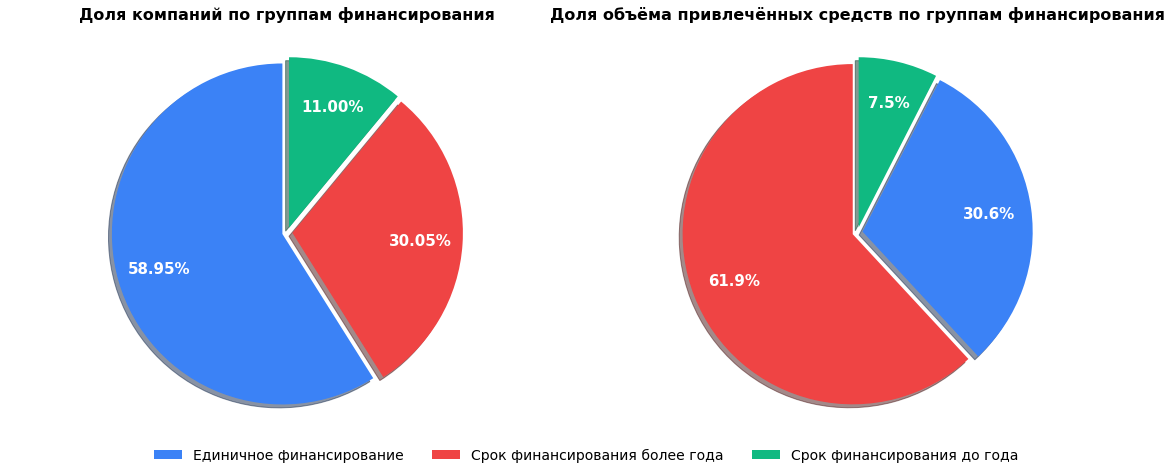

In [50]:
# Общие настройки стиля
fontsize_title = 16
fontsize_labels = 14
fontsize_autopct = 15
explode = (0.03, 0.03, 0.03)
shadow = True
startangle = 90
pctdistance = 0.75
figsize = (16, 7)
pad_title = 20

# Подготовка данных 
sizes1 = list(result_df['Доля (%)'])
colors1 = [group_colors[lbl] for lbl in result_df['Группа']]

sizes2 = list(grouped_funding['Доля в общем объёме, %'])
colors2 = [group_colors[lbl] for lbl in grouped_funding['Группа финансирования']]

# Создаём два графика рядом
fig, axes = plt.subplots(1, 2, figsize=figsize)
ax_left, ax_right = axes

# Функция для рисования круговой диаграммы
def draw_pie(ax, sizes, colors, title, fmt):
    wedges, _, autotexts = ax.pie(
        sizes, labels=None, autopct=fmt, startangle=startangle, colors=colors,
        explode=explode, shadow=shadow, pctdistance=pctdistance
    )
    ax.set_title(title, fontsize=fontsize_title, pad=pad_title, fontweight='bold')
    ax.axis('equal')
    for autotext in autotexts:
        autotext.set_fontsize(fontsize_autopct)
        autotext.set_fontweight('bold')
        autotext.set_color('white')
        autotext.set_family('sans-serif')
    return wedges

# Рисуем графики
wedges1 = draw_pie(ax_left, sizes1, colors1, 'Доля компаний по группам финансирования', '%1.2f%%')
wedges2 = draw_pie(ax_right, sizes2, colors2, 'Доля объёма привлечённых средств по группам финансирования', '%1.1f%%')

# Общая легенда внизу фигуры
labels = list(result_df['Группа'])

fig.legend(
    wedges1,
    labels,
    loc='lower center',
    ncol=len(labels),
    fontsize=fontsize_labels,
    frameon=False
)

# Оставляем место снизу под легенду
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()
plt.close(fig)

По количеству компаний доминирует группа «Единичное финансирование»: на неё приходится 59 % всех компаний - это явный признак того, что большинство стартапов проваливаются (за исключением случаев когда стартап сразу был выкуплен крупной компанией). Это почти в 2 раза больше, чем у второй по численности группы («Срок финансирования более года» — 30 %), и в 5.4 раза больше, чем у «до года» (11 %). 

По объёму инвестиций картина противоположная: лидер — группа «Срок финансирования более года»: 402,71 млрд USD (61,9 % от общего объёма).

[Назад к содержанию](#start)

---
<a id='6'></a>
***3.1.2 Выделение средних и нишевых сегментов рынка***

Посмотрим как часто в датасете встречается каждый из сегментов рынка, указаный в столбце `market`. Разделим сегменты на категории:
* Массовые - сегменты, к которым относится более 120 компаний;
* Средние - сегменты, в которые входит от 35 до 120 включительно;
* Нишевые - сегменты до 35 компаний. 

In [51]:
# Приводим названия сегментов к единому стилю (нижний регистр + убираем лишние пробелы)
df_invest_clean['market'] = (
    df_invest_clean['market']
    .str.strip()               
    .str.lower()               
)

In [52]:
# Считаем частоту каждого сегмента
market_counts = df_invest_clean['market'].value_counts()

In [53]:
# Разделим на категории
massive_segments = market_counts[market_counts > 120]
mid_segments     = market_counts[(market_counts >= 35) & (market_counts <= 120)]
niche_segments   = market_counts[market_counts < 35]

In [54]:
# Считаем количество сегментов в каждой категории
num_massive = len(massive_segments)
num_mid     = len(mid_segments)
num_niche   = len(niche_segments)

In [55]:
# Общее количество сегментов
total_segments = num_massive + num_mid + num_niche

In [56]:
# Считаем доли в процентах
pct_massive = (num_massive / total_segments) * 100
pct_mid     = (num_mid / total_segments) * 100
pct_niche   = (num_niche / total_segments) * 100

print("Распределение по количеству СЕГМЕНТОВ:")
print(f"Массовые сегменты (>120 компаний): {num_massive} сегментов ({pct_massive:.1f}%)")
print(f"Средние сегменты (35–120 компаний): {num_mid} сегментов ({pct_mid:.1f}%)")
print(f"Нишевые сегменты (<35 компаний): {num_niche} сегментов ({pct_niche:.1f}%)")

Распределение по количеству СЕГМЕНТОВ:
Массовые сегменты (>120 компаний): 48 сегментов (12.2%)
Средние сегменты (35–120 компаний): 57 сегментов (14.5%)
Нишевые сегменты (<35 компаний): 289 сегментов (73.4%)


In [57]:
# Считаем количество компаний по категориям
total_massive = massive_segments.sum()
total_mid     = mid_segments.sum()
total_niche   = niche_segments.sum()

# Общее количество компаний
total_companies = total_massive + total_mid + total_niche

# Считаем доли в процентах
pct_massive_comp = (total_massive / total_companies) * 100
pct_mid_comp     = (total_mid / total_companies) * 100
pct_niche_comp   = (total_niche / total_companies) * 100

print("\nРаспределение по количеству КОМПАНИЙ:")
print(f"В массовых сегментах: {total_massive:,} компаний ({pct_massive_comp:.1f}%)")
print(f"В средних сегментах:   {total_mid:,} компаний ({pct_mid_comp:.1f}%)")
print(f"В нишевых сегментах:   {total_niche:,} компаний ({pct_niche_comp:.1f}%)")


Распределение по количеству КОМПАНИЙ:
В массовых сегментах: 33,731 компаний (87.8%)
В средних сегментах:   3,839 компаний (10.0%)
В нишевых сегментах:   830 компаний (2.2%)


Построим график распределения количества компаний в сегментах, для наглядности выделим топ-15. Также отобразим сколько компаний приходится на каждый сегмент.

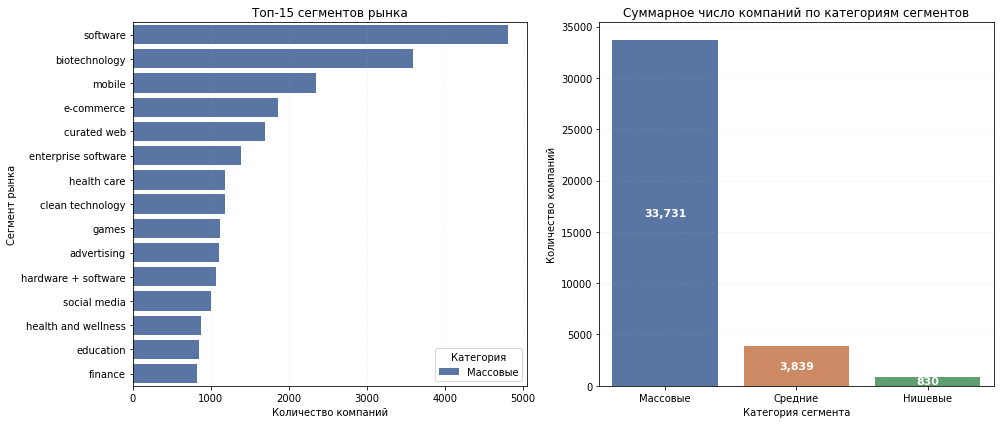

In [58]:
# Агрегируем данные по трём категориям сегментов для визуализации
category_totals = pd.DataFrame({
    'category': ['Массовые', 'Средние', 'Нишевые'],
    'total_companies': [total_massive, total_mid, total_niche]
})

# Топ‑15 сегментов 
TOP_N = 15
top_15 = market_counts.head(TOP_N).reset_index()
top_15.columns = ['market', 'count']

# Функция присвоения категории 
def get_category(count):
    if count > 120:
        return 'Массовые'
    elif 35 <= count <= 120:
        return 'Средние'
    else:
        return 'Нишевые'

top_15['category'] = top_15['count'].apply(get_category)

# Настроим цвета
palette = {'Массовые': '#4c72b0', 'Средние': '#dd8452', 'Нишевые': '#55a868'}

# Два графика рядом 
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Топ‑15 
sns.barplot(data=top_15, y='market', x='count', hue='category', dodge=False, palette=palette, ax=axs[0])
axs[0].set_title(f'Топ-{TOP_N} сегментов рынка')
axs[0].set_xlabel('Количество компаний')
axs[0].set_ylabel('Сегмент рынка')
axs[0].grid(axis='x', linestyle=':', alpha=0.3)
axs[0].legend(title='Категория')

# График 2: Суммарное число компаний по категориям 
sns.barplot(data=category_totals, x='category', y='total_companies',
            ax=axs[1], palette=[palette[c] for c in category_totals['category']])
axs[1].set_title('Суммарное число компаний по категориям сегментов')
axs[1].set_xlabel('Категория сегмента')
axs[1].set_ylabel('Количество компаний')
axs[1].grid(axis='y', linestyle=':', alpha=0.3)

# Добавляем подписи внутри столбцов
for p in axs[1].patches:
    height = p.get_height()
    y_pos = p.get_y() + p.get_height() / 2
    

    axs[1].annotate(
        f'{int(height):,}',
        xy=(p.get_x() + p.get_width() / 2, y_pos),
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        color='white'  
    )
plt.tight_layout()

# Выводим график
plt.show()

Свыше 80 % компаний сосредоточено в 48 массовых сегментах. При этом структура остаётся сильно фрагментированной — 73 % сегментов относятся к нишевым, что отражает многообразие узкоспециализированных направлений. 

Топ‑15 сегментов задают основной вектор рынка. На графике видно, что лидеры (software, biotechnology, mobile и др.) имеют кратно большее число компаний по сравнению с остальными. Это «ядро» рынка, где сосредоточена основная активность и, вероятно, основной объём выручки и инвестиций. 

---

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних. Дальнейшие исследования будем выполнять с учётом этой замены.

In [59]:
# Создаём копию датафрейма
df_agg = df_invest_clean.copy()

def normalize_market(market_name):
    count = market_counts.get(market_name, 0)
    if count > 120:
        # Массовые: оставляем оригинальное название
        return market_name
    elif 35 <= count <= 120:
        # Средние: заменяем на заглушку
        return 'mid'
    else:
        # Нишевые: заменяем на заглушку
        return 'niche'

# Применяем функцию ко всему столбцу market
df_agg['market'] = df_agg['market'].apply(normalize_market)

# Проверка:
print("Уникальные значения в market после агрегации:")
print(df_agg['market'].unique())
print(f"Всего уникальных значений: {df_agg['market'].nunique()}")

Уникальные значения в market после агрегации:
['education' 'niche' 'mid' 'social media' 'hardware + software'
 'biotechnology' 'hospitality' 'enterprise software' 'manufacturing'
 'finance' 'design' 'nonprofits' 'software' 'curated web' 'health care'
 'health and wellness' 'clean technology' 'web hosting' 'e-commerce'
 'automotive' 'medical' 'fashion' 'security' 'networking' 'analytics'
 'semiconductors' 'public relations' 'travel' 'consulting' 'real estate'
 'technology' 'music' 'advertising' 'games' 'mobile' 'internet' 'sports'
 'photography' 'news' 'search' 'messaging' 'video' 'marketplaces'
 'entertainment' 'saas' 'cloud computing' 'big data' 'apps'
 'social network media' 'startups']
Всего уникальных значений: 50


***ПРОМЕЖУТОЧНЫЕ ВЫВОДЫ:*** 

* Компании были разделены на три группы по срокам финансирования: всего один раунд (58.9%), до года (11%), более года (30.1%). По объему инвестиций (доля от общего объёма привлечённых средств) данные группы имеют 30.6%, 7.5% и 61.9% соответсвенно.
* Были выделены категории сегментов рынка по частоте встречания в датасете: массовые (12.2% сегментов) - к ним относится 87.8% компаний; средние (14.5% сегментов) - 10.0 % компаний и нишевые (73.4% сегментов) - 2.2% компаний. 
* Найден топ-15 сегментов рынка. Первые три: software, biotechnology, mobile. 
* Для средих и нишевых сегментов поставлены заглушки, чтобы в дальнейшем сконцентрироваться на анализе массовых сегментов. 
* Рынок стартапов поляризован: небольшое число массовых сегментов концентрирует подавляющую часть компаний, тогда как большинство сегментов — нишевые и включают минимум игроков. Такая поляризация делает рынок устойчивым. Массовые сегменты обеспечивают ликвидность, стабильные выходы (exits) инвесторов и общую видимость отрасли, а длинный хвост из тысяч ниш гарантирует постоянный приток инноваций и защищает экономику от стагнации, не давая ей зависеть от нескольких перегретых направлений. 

[Назад к содержанию](#start)

---

### Работа с выбросами и анализ типов финансирования
<a id='7'></a>
***3.2.1 Анализ выбросов в каждом из сегментов***

Сначала оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся и найдем интервал, в котором лежат типичные значения.

In [60]:
# Проанализируем статистические показатели данных
df_agg['funding_total_usd'].describe()

count           40,900.00
mean        15,906,960.90
std        168,687,615.39
min                  1.00
25%            350,000.00
50%          2,000,000.00
75%         10,000,000.00
max     30,079,503,000.00
Name: funding_total_usd, dtype: float64

Минимальное значение = 1, посмотрим топ минимальных сумм инвестиций для понимания, насколько это "нормальная" цифра.

In [61]:
# Отсортируем строки по возрастанию суммы инвестиций
top_5_min = (
    df_agg[df_agg['funding_total_usd'] > 0]
    .sort_values('funding_total_usd')
    .head(5)[['name', 'market', 'funding_total_usd']]
)

top_5_min

,name,market,funding_total_usd
48817,Deck Works.co,design,1.00
38402,MICEit.co,niche,14.00
3549,Enviance,software,22.00
38541,The Manly Man Can,fashion,30.00
36888,Snapstream,software,50.00


In [62]:
# Переводим в млн USD
df_agg['funding_total_mln'] = df_agg['funding_total_usd'] / 1_000_000

In [63]:
# Считаем границы и медиану
med = df_agg['funding_total_mln'].median()
q1 = df_agg['funding_total_mln'].quantile(0.25)
q3 = df_agg['funding_total_mln'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

print(f"Типичный размер финансирования (медиана): {med:.2f} млн USD")
print(f"Типичный интервал (25–75%): {q1:.2f} – {q3:.2f} млн USD")
print(f"Граница выбросов: > {upper_bound:.2f} млн USD")

Типичный размер финансирования (медиана): 2.00 млн USD
Типичный интервал (25–75%): 0.35 – 10.00 млн USD
Граница выбросов: > 24.48 млн USD


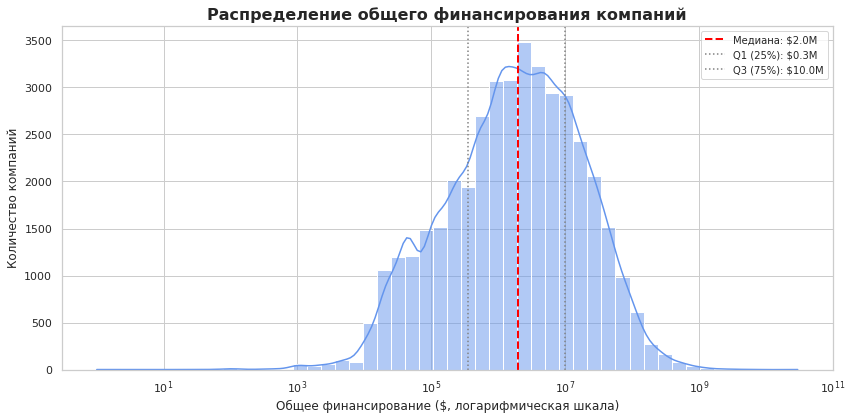

In [64]:
# Настройка стиля графика
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))

# Строим гистограмму. 
# log_scale=(True, False) — логарифм только по оси X, чтобы не искажать количество компаний на оси Y
ax = sns.histplot(
    data=df_agg, 
    x='funding_total_usd', 
    bins=50, 
    kde=True, # Добавляет линию графика плотности (KDE), чтобы видеть форму "хвоста"
    log_scale=(True, False),
    color='cornflowerblue'
)

# Оформление осей и заголовка
ax.set_title('Распределение общего финансирования компаний', fontsize=16, weight='bold')
ax.set_xlabel('Общее финансирование ($, логарифмическая шкала)', fontsize=12)
ax.set_ylabel('Количество компаний', fontsize=12)

# Для наглядности добавим линии медианы и квартилей прямо на график
q1 = df_agg['funding_total_usd'].quantile(0.25)
med = df_agg['funding_total_usd'].median()
q3 = df_agg['funding_total_usd'].quantile(0.75)

ax.axvline(med, color='red', linestyle='--', linewidth=2, label=f'Медиана: ${med/1e6:.1f}M')
ax.axvline(q1, color='gray', linestyle=':', linewidth=1.5, label=f'Q1 (25%): ${q1/1e6:.1f}M')
ax.axvline(q3, color='gray', linestyle=':', linewidth=1.5, label=f'Q3 (75%): ${q3/1e6:.1f}M')

ax.legend(fontsize=10)
plt.tight_layout()

# Выводим график
plt.show()

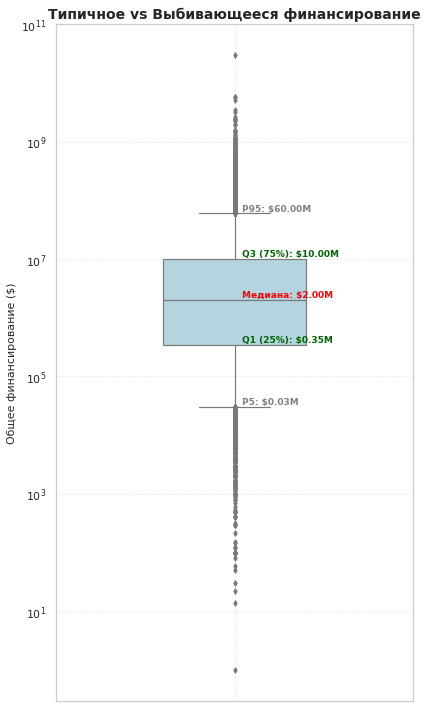

In [65]:
# Настройка стиля
sns.set(style="whitegrid")
# Настройка фигуры
plt.figure(figsize=(6, 10))

# Строим boxplot 
ax = sns.boxplot(
    y=df_agg['funding_total_usd'],
    width=0.4,
    color='lightblue',
    fliersize=4,          
    linewidth=1.2,
    whis=(5, 95)          # Оставляем ограничение усов
)

# Включаем логарифмическую шкалу
ax.set_yscale('log') 

# Оформление графика
ax.set_title('Типичное vs Выбивающееся финансирование', fontsize=14, weight='bold')
ax.set_ylabel('Общее финансирование ($)', fontsize=11)
ax.grid(True, which="both", ls="--", alpha=0.3)

# Рассчитаем границы для наглядных меток
p5 = df_agg['funding_total_usd'].quantile(0.05)
p95 = df_agg['funding_total_usd'].quantile(0.95)

x_pos = 0.02
offset_y = 1.2
labels = [
    f'P5: ${p5/1e6:.2f}M',
    f'Q1 (25%): ${q1/1e6:.2f}M',
    f'Медиана: ${med/1e6:.2f}M',
    f'Q3 (75%): ${q3/1e6:.2f}M',
    f'P95: ${p95/1e6:.2f}M'
]
positions = [p5, q1, med, q3, p95]
colors = ['gray', 'darkgreen', 'red', 'darkgreen', 'gray']

for pos, lab, col in zip(positions, labels, colors):
    ax.text(x_pos, pos * offset_y, lab, va='center', ha='left', fontsize=9, fontweight='semibold', color=col)

plt.tight_layout()

# Выводим график
plt.show()

* Исходя из данных с аномальными значениями типичный размер финансирования (медиана): 2,0 млн USD.
* Интервал типичных значений (межквартильный размах 25–75%): от 0,35 до 10,0 млн USD. В нём находится половина всех компаний. 
* Статистические выбросы: всё, что выше примерно 24,5 млн USD.
* Экстремальные выбросы: значения, находящиеся далеко за третьим квартилем. Судя по среднему значению (почти 16 млн) при медиане в 2 млн и стандартному отклонению в 168 млн, таких точек немного, но они колоссальны. Максимальное значение (более 30 млрд долларов) является абсолютным аномальным выбросом, который тянет всю правую часть распределения. 

---
<a id='9'></a>
Определим компании с аномальным объёмом общего финансирования (методом IQR отдельно по каждому сегменту) и найдем сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

In [66]:
# Вычисляем границы IQR для объединенных групп ('mid' и 'niche')
q1_mid = df_agg[df_agg['market'] == 'mid']['funding_total_mln'].quantile(0.25)
q3_mid = df_agg[df_agg['market'] == 'mid']['funding_total_mln'].quantile(0.75)
iqr_mid = q3_mid - q1_mid
lower_mid = q1_mid - 1.5 * iqr_mid
upper_mid = q3_mid + 1.5 * iqr_mid

q1_niche = df_agg[df_agg['market'] == 'niche']['funding_total_mln'].quantile(0.25)
q3_niche = df_agg[df_agg['market'] == 'niche']['funding_total_mln'].quantile(0.75)
iqr_niche = q3_niche - q1_niche
lower_niche = q1_niche - 1.5 * iqr_niche
upper_niche = q3_niche + 1.5 * iqr_niche

In [67]:
# Для массовых сегментов сохраним словари с границами, рассчитав их циклом
massive_bounds = {}
for seg in massive_segments.index:
    data = df_agg[df_agg['market'] == seg]['funding_total_mln']
    if not data.empty:
        q1, q3 = data.quantile([0.25, 0.75])
        iqr = q3 - q1
        massive_bounds[seg] = {
            'lower': q1 - 1.5 * iqr,
            'upper': q3 + 1.5 * iqr
            }

In [68]:
# Функция определения аномалии
def is_anomaly(row):
    mkt = row['market']
    val = row['funding_total_mln']
    
    # Проверяем нишевые сегменты
    if mkt == 'niche':
        return val < lower_niche or val > upper_niche
    # Проверяем средние сегменты
    elif mkt == 'mid':
        return val < lower_mid or val > upper_mid
    # Проверяем конкретные массивные сегменты
    else:
        bounds = massive_bounds.get(mkt)
        if bounds:
            return val < bounds['lower'] or val > bounds['upper']
        return False # На случай пустых данных

# Применяем функцию 
df_agg['is_funding_outlier'] = df_agg.apply(is_anomaly, axis=1)

In [69]:
# Анализ долей аномалий по сегментам
# Группируем по столбцу 'market'
agg_stats = df_agg.groupby('market').agg(
    total_count=('funding_total_mln', 'count'),
    outlier_count=('is_funding_outlier', 'sum')
).reset_index()

agg_stats['outlier_share'] = agg_stats['outlier_count'] / agg_stats['total_count'] 

# Сортируем по убыванию доли аномалий
top_anomalous_segments = agg_stats.sort_values('outlier_share', ascending=False)

# Выведем топ-10 сегментов с наибольшей долей аномального финансирования
top_anomalous_segments.head(10)

,market,total_count,outlier_count,outlier_share
36,real estate,279,48,0.17
14,entertainment,150,25,0.17
8,consulting,349,58,0.17
38,search,291,48,0.16
7,cloud computing,152,25,0.16
37,saas,272,44,0.16
34,photography,204,33,0.16
46,technology,238,38,0.16
48,video,188,30,0.16
47,travel,330,51,0.15


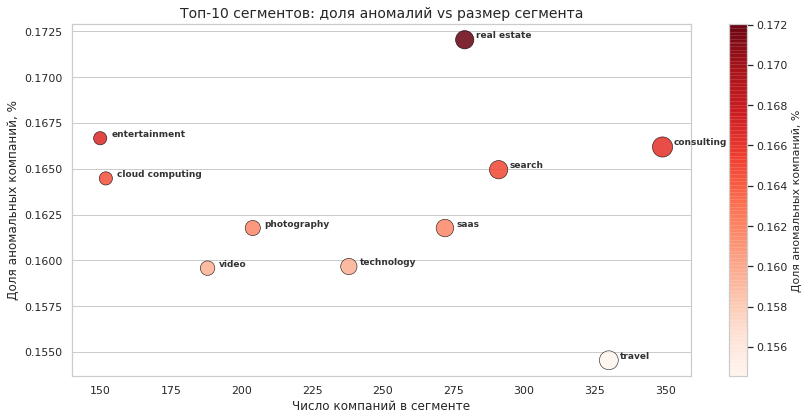

In [70]:
# Берём топ‑10 сегментов по доле аномалий
df_plot = top_anomalous_segments.head(10).copy()
df_plot = df_plot.sort_values('outlier_share', ascending=False)

# Задаём размер фигуры 
fig, ax = plt.subplots(figsize=(12, 6))

# Рассчитываем размеры точек 
sizes = [c * 7 for c in df_plot['outlier_count']]

# Рисуем scatter-график
scatter = ax.scatter(
    df_plot['total_count'],          # ось X: размер сегмента (число компаний)
    df_plot['outlier_share'],        # ось Y: доля аномальных компаний (%)
    s=sizes,                         # размер точки = число аномальных компаний
    c=df_plot['outlier_share'],      
    cmap='Reds',                     
    edgecolors='black',              
    linewidth=0.6,                   
    alpha=0.85,                      
    zorder=3                         
)

# Подписи осей и заголовок
ax.set_xlabel('Число компаний в сегменте', fontsize=12)
ax.set_ylabel('Доля аномальных компаний, %', fontsize=12)
plt.title('Топ‑10 сегментов: доля аномалий vs размер сегмента', fontsize=14)

# Добавляем подписи названий сегментов рядом с точками
for i, row in df_plot.iterrows():
    ax.text(
        row['total_count'] + 4,
        row['outlier_share'],
        row['market'],
        fontsize=9,
        ha='left',
        va='bottom',
        fontweight='bold',
        color='#333333'
    )

# Добавляем цветовую шкалу (colorbar) 
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Доля аномальных компаний, %', fontsize=11)

# Включаем сетку по оси X
ax.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

# Выводим график
plt.show()

Доля аномальных компаний в топ‑10 колеблется от 15% до 17% — очень плотный диапазон. Это значит, что в этих сегментах аномальное финансирование — не единичные выбросы, а системная особенность: в каждом из них примерно каждый шестой стартап получает «нетипичный» объём денег.

[Назад к содержанию](#start)

---
<a id='8'></a>
***3.2.2 Определяем границы рассматриваемого периода, отбрасываем аномалии***

Проверим по датасету, полные ли данные у нас за 2014 год, для этого вначале посмотрим есть ли даты после 2014 года.

In [71]:
after_2014 = df_agg['last_funding_at'].dt.year > 2014
after_2014.sum()

0

В данных нет компаний с последним раундом после 2014 года. Теперь проверим распределение событий по месяцам за 2014 год.

In [72]:
# Извлекаем 2014 год
in_2014_last = df_agg[df_agg['last_funding_at'].dt.year == 2014]

# Считаем частоту событий по месяцам
monthly_last_2014 = in_2014_last['last_funding_at'].dt.month.value_counts().sort_index()

# Выводим результат
monthly_last_2014

1     1178
2      947
3     1072
4     1077
5     1036
6     1229
7     1253
8     1064
9     1134
10    1139
11     730
12      52
Name: last_funding_at, dtype: int64

В декабре всего 52 события против 730 в ноябре и ~1100 в предыдущие месяцы. Такой резкий обрыв в конце года означает либо что данные собирали до середины декабря, либо выгрузка сделана по состоянию «на конец ноября», либо в декабре просто не успели зафиксировать раунды.

Посмотрим еще долю компаний, у которых в 2014 году был короткий цикл финансирования (до 30 дней), если таких аномально много, это будет говорить о неполноте данных за 2014 год.

In [73]:
# Расчет длительности цикла
df_agg['duration_days'] = (
    df_agg['last_funding_at'] - df_agg['first_funding_at']
).dt.days

in_2014_last = df_agg[df_agg['last_funding_at'].dt.year == 2014]
# Выбираем строки, где длительность цикла не больше 30 дней
short_cycles = in_2014_last[in_2014_last['duration_days'] <= 30]

# Считается доля «сверхкоротких» циклов среди всех компаний с last_year == 2014
len(short_cycles) / len(in_2014_last)

0.49743934178490473

В 2014 году почти 50 % циклов короче 30 дней — это статистически аномально и объясняется неполнотой данных (подтверждается также резким падением числа событий в декабре).  Многие компании попали в категорию "последний раунд в 2014" не потому, что их финансирование завершилось, а потому, что в датасет не включены раунды после 2014.

---

Исключим из датасета компании, которые ранее посчитали получившими аномальное финансирование [(п 3.2.1)](#9).

In [74]:
# Исключаем аномалии: оставляем только строки, где is_funding_outlier = False
df_clean_no_outlier = df_agg[df_agg['is_funding_outlier'] == False].copy()

# Считаем количества
total_rows = len(df_agg)
clean_rows = len(df_clean_no_outlier)
removed_rows = total_rows - clean_rows

# Считаем проценты
percent_removed = (removed_rows / total_rows) * 100

print(f"Всего строк: {total_rows}")
print(f"Строк после очистки: {clean_rows}")
print(f"Удалено строк: {removed_rows}")
print(f"Процент удалённых: {percent_removed:.2f}%")

Всего строк: 40900
Строк после очистки: 35686
Удалено строк: 5214
Процент удалённых: 12.75%


In [75]:
# Посмотрим статистику после исключения аномальных значений
df_clean_no_outlier['funding_total_usd'].describe()

count       35,686.00
mean     4,529,359.65
std      8,024,762.35
min              1.00
25%        250,000.00
50%      1,312,500.00
75%      5,000,000.00
max     74,989,194.00
Name: funding_total_usd, dtype: float64

In [76]:
# Считаем границы и медиану
med = df_clean_no_outlier['funding_total_mln'].median()
q1 = df_clean_no_outlier['funding_total_mln'].quantile(0.25)
q3 = df_clean_no_outlier['funding_total_mln'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

print(f"Типичный размер финансирования (медиана): {med:.2f} млн USD")
print(f"Типичный интервал (25–75%): {q1:.2f} – {q3:.2f} млн USD")
print(f"Граница выбросов: > {upper_bound:.2f} млн USD")

Типичный размер финансирования (медиана): 1.31 млн USD
Типичный интервал (25–75%): 0.25 – 5.00 млн USD
Граница выбросов: > 12.12 млн USD


---

На основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об компаниях, у которых даты финансирования попадают в годы, когда было зафиксировано 50 или более раундов финансирования.

In [77]:
# Извлекаем год
df_clean_no_outlier['mid_year'] = df_clean_no_outlier['mid_funding_at'].dt.year

In [78]:
# Считаем суммарное число раундов по годам
rounds_by_year = df_clean_no_outlier.groupby('mid_year')['funding_rounds'].sum()

In [79]:
# Оставляем только годы, где суммарно >= 50 раундов
valid_years = rounds_by_year[rounds_by_year >= 50].index

In [80]:
# Фильтруем датасет
df_final = df_clean_no_outlier[df_clean_no_outlier['mid_year'].isin(valid_years)].copy()

In [81]:
# Сводка для отчёта
total_rows = len(df_clean_no_outlier)
final_rows = len(df_final)
removed_rows = total_rows - final_rows
percent_removed = (removed_rows / total_rows) * 100

print(f"Было строк (после удаления аномалий): {total_rows}")
print(f"Стало строк (после фильтрации по годам): {final_rows}")
print(f"Удалено строк: {removed_rows}")
print(f"Процент удалённых: {percent_removed:.2f}%")
print("Валидные годы (>=50 раундов):", sorted(valid_years.tolist()))

Было строк (после удаления аномалий): 35686
Стало строк (после фильтрации по годам): 35612
Удалено строк: 74
Процент удалённых: 0.21%
Валидные годы (>=50 раундов): [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]


***ПРОМЕЖУТОЧНЫЕ ВЫВОДЫ:***
* Был выявлен топ сегментов с наибольшими долями аномального финансирования. Первые три: real estate, entertainment, consulting, у всех по 17% аномалий.
* Есть предположение, что за 2014 год предоставлены неполные данные, так как наблюдается обрыв данных в конце года.
* Из выборки были исключены аномальные значения. 
* Типичный размер финансирования (медиана): 1.31 млн USD. Интервал, в котором лежат типичные значения: 0.25 – 5.00 млн USD.
* Для дальнейшего анализа оставили только 2000-2014 года (в них было зафиксировано 50 или более раундов финансирования).

[Назад к содержанию](#start)

---
<a id='10'></a>
***3.2.3 Анализ типов финансирования по объёму и популярности***

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. 

In [82]:
# Создадим список столбцов с типами финансирования
cols = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

In [83]:
# Считаем сумму по каждому типу финансирования
funding_sum = df_final[cols].sum()

# Сортируем по убыванию
funding_sum_sorted = funding_sum.sort_values(ascending=False)

In [84]:
# Сохраняем в датафрейм
funding_df = pd.DataFrame({
    'Общая сумма, млн USD': funding_sum_sorted / 1e6,          
})

funding_df

,"Общая сумма, млн USD"
venture,"129,067.83"
seed,"9,441.75"
debt_financing,"8,190.78"
private_equity,"4,830.73"
angel,"2,477.92"
undisclosed,"2,088.89"
grant,"2,002.17"
post_ipo_equity,"1,930.55"
convertible_note,566.04
post_ipo_debt,286.72


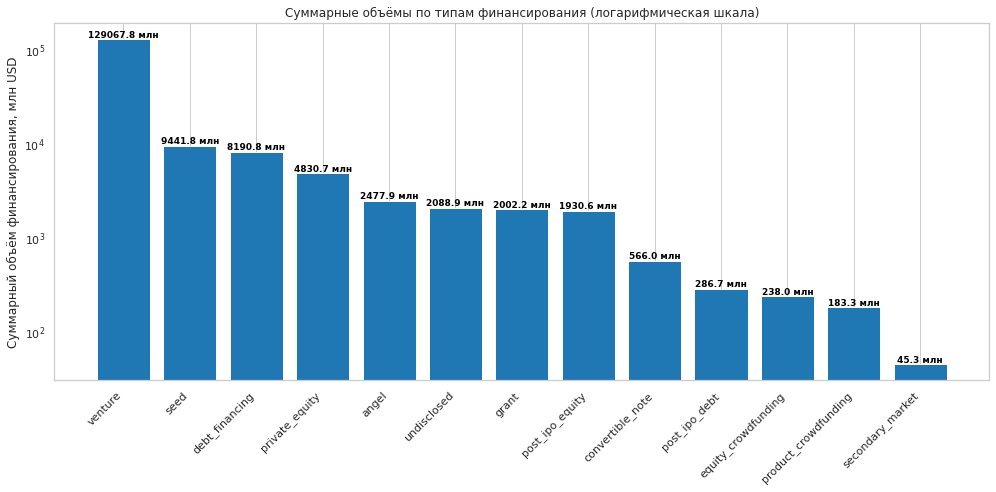

In [85]:
# Создаем график
fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(funding_df.index, funding_df['Общая сумма, млн USD'], color= '#1f77b4')

# Подписи на столбцах
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f} млн",
        ha='center', va='bottom', fontsize=9, fontweight='bold', color='black'
    )

# Оформление заголовка и осей
ax.set_ylabel('Суммарный объём финансирования, млн USD')
ax.set_title('Суммарные объёмы по типам финансирования (логарифмическая шкала)')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')

# Логарифмическая шкала по Y 
ax.set_yscale('log')

plt.tight_layout()

# Вывод графика
plt.show()

Теперь построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

In [86]:
# Считаем, сколько раз встречается каждый тип
usage_counts = {}
for col in cols:
    count = (df_final[col].notna() & (df_final[col] != 0)).sum()
    usage_counts[col] = count

usage_df = pd.DataFrame.from_dict(usage_counts, orient='index', columns=['Число записей'])

# Сортируем по убыванию
usage_df = usage_df.sort_values('Число записей', ascending=False)

usage_df

,Число записей
venture,18836
seed,13372
debt_financing,3268
angel,2935
grant,1006
undisclosed,814
private_equity,636
convertible_note,521
equity_crowdfunding,515
product_crowdfunding,204


Так как самые популярные типы финансирования сильно доминируют над остальными, на графике покажем топ‑6 и все остальные типы складываем в «Прочие».

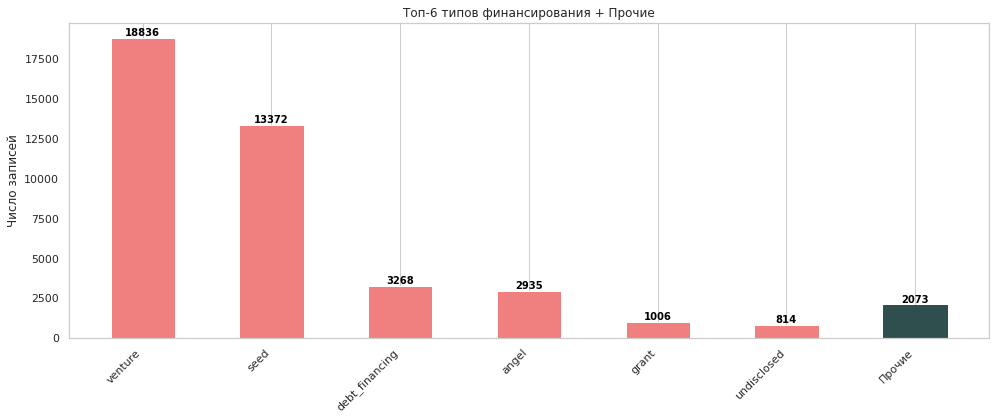

In [87]:
top_n = 6
# Выделяем топ‑6 и «Прочие»
top_categories = usage_df.head(top_n)
others_sum = usage_df['Число записей'].iloc[top_n:].sum()

# Формируем данные для графика
plot_df = top_categories.copy()
plot_df.loc['Прочие'] = others_sum

# Строим график
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(plot_df.index, plot_df['Число записей'], width=0.5, color='lightcoral')

# Меняем цвет столбца «Прочие» 
idx_others = list(plot_df.index).index('Прочие')
bars[idx_others].set_color('#2f4f4f')  

# Подписи на столбцах
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{int(h)}",
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='black'
    )

# Оформления заголовка и осей
ax.set_ylabel('Число записей')
ax.set_title(f'Топ-{top_n} типов финансирования + Прочие')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Выводим график
plt.show()

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [88]:
# Объединяем два датафрейма по индексу 
merged_df = funding_df.join(usage_df)

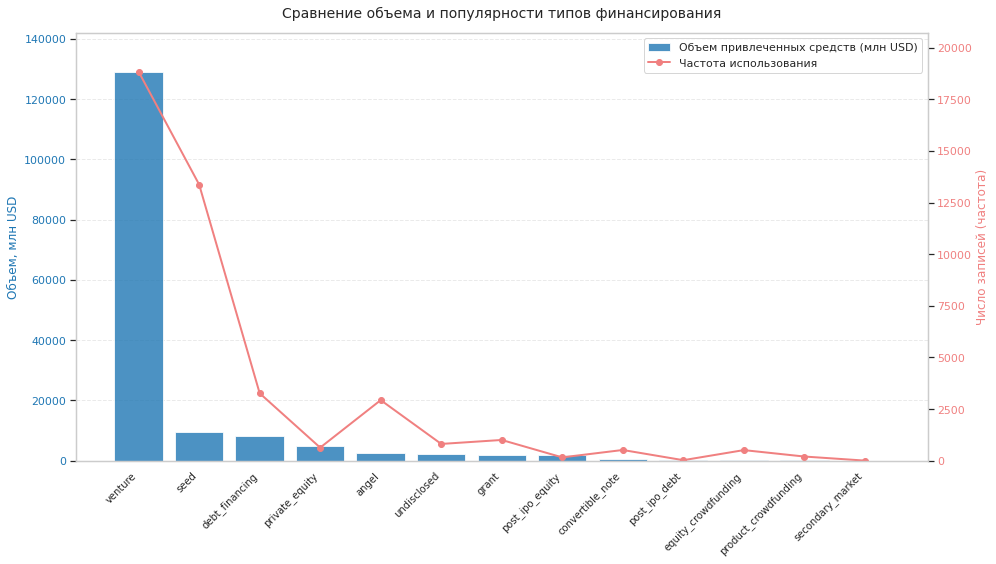

In [89]:
# Инициализация графика с двумя осями Y
fig, ax1 = plt.subplots(figsize=(14, 8))

# Настройка цветов
color_vol = '#1f77b4'       # Синий для объема
color_freq = 'lightcoral'   # Светло‑коралловый для частоты

# Левая ось: столбцы объема финансирования
bars = ax1.bar(
    merged_df.index, 
    merged_df['Общая сумма, млн USD'], 
    color=color_vol, 
    label='Объем привлеченных средств (млн USD)',
    alpha=0.8
)

ax1.set_ylabel('Объем, млн USD', fontsize=12, color=color_vol)
ax1.tick_params(axis='y', labelcolor=color_vol)
ax1.set_ylim(0, merged_df['Общая сумма, млн USD'].max() * 1.1)

# Правая ось: линия частоты использования
ax2 = ax1.twinx()

line = ax2.plot(
    merged_df.index, 
    merged_df['Число записей'], 
    color=color_freq, 
    marker='o', 
    linewidth=2, 
    markersize=6, 
    label='Частота использования'
)

ax2.set_ylabel('Число записей (частота)', fontsize=12, color=color_freq)
ax2.tick_params(axis='y', labelcolor=color_freq)
ax2.set_ylim(0, merged_df['Число записей'].max() * 1.1)

# Заголовок
ax1.set_title('Сравнение объема и популярности типов финансирования', fontsize=14, pad=15)

# Убираем сетку
ax1.grid(False)
ax2.grid(False)

# Поворот подписей на оси X (через ax1, а не plt)
ax1.tick_params(axis='x', labelrotation=45, labelsize=10)
ax1.set_xticks(range(len(merged_df.index)))
ax1.set_xticklabels(merged_df.index, ha='right')

# Включаем сетку только по оси Y на левой оси 
ax1.grid(axis='y', linestyle='--', alpha=0.4) 

# Объединение легенд
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout()
# Выводим график
plt.show()

Для сравнения частоты и объема финансирования расчитаем средний чек для каждого типа.

In [90]:
# Добавляем столбец «Средний чек, млн USD»
merged_df['Средний чек, млн USD'] = (
    merged_df['Общая сумма, млн USD'] / merged_df['Число записей']
).round(3)

merged_df

,"Общая сумма, млн USD",Число записей,"Средний чек, млн USD"
venture,"129,067.83",18836,6.85
seed,"9,441.75",13372,0.71
debt_financing,"8,190.78",3268,2.51
private_equity,"4,830.73",636,7.59
angel,"2,477.92",2935,0.84
undisclosed,"2,088.89",814,2.57
grant,"2,002.17",1006,1.99
post_ipo_equity,"1,930.55",163,11.84
convertible_note,566.04,521,1.09
post_ipo_debt,286.72,27,10.62


***ПРОМЕЖУТОЧНЫЕ ВЫВОДЫ:***

На рынке доминирует сегмент ***venture***: на него приходится 129 068 млн USD — это более 80 % от общей суммы при наибольшем числе сделок (18 836). При этом средний чек здесь умеренный (6,85 млн USD), что говорит о масштабной, но сбалансированной активности.

Типы финансирования, которые часто встречаются, но характеризуются небольшими объёмами:
* ***Seed: 9 441.75 млн USD | 13 372 раза.***  Несмотря на внушительную общую сумму, средний чек здесь один из самых низких среди топ-категорий (~0.7 млн USD), так как инструмент применяется массово.
* ***Angel: 2 477.92 млн USD | 2 935 раз.*** Самый массовый посевной капитал от частных лиц. Много сделок, но они мелкие.
* ***Equity_crowdfunding: 237.96 млн USD | 515 раз*** Краудинвестинг по определению состоит из множества мелких взносов.
* ***Convertible Note: 566.04 млн USD | 521 раз.*** Популярный юридический механизм отложенной оценки. Удобен для быстрых раундов, поэтому встречается часто, но суммы обычно невелики.

Типы финансирования, которые встречаются редко, но характеризуются значительным объёмом:
* ***Private Equity: 4 830.73 млн USD | 636 раз.*** Хотя частота использования выше, чем у долгового капитала, этот тип характеризуется крупным чеком (~7.6 млн USD). Это деньги фондов прямых инвестиций, которые заходят в зрелые компании большими траншами.
* ***Post-IPO Debt: 286.72 млн USD | 27 раз.*** Крайне редкий инструмент для публичных гигантов, привлекающих долг после выхода на биржу. Средний чек превышает 10 млн долларов.
* ***Debt Financing: 8 190.78 млн USD | 3 268 раз.*** Банковское кредитование или выпуск облигаций технологическими компаниями. Используется реже венчура, но каждая сделка приносит значительно больше денег (средний чек ~2.5 млн USD).
* ***Post_ipo_equity: 1,930.55	млн USd | 163 раз.*** Самый крупный чек (~11,84 млн USD) в выборке при очень низкой частоте.

[Назад к содержанию](#start)

---

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датафрейма `df_return`.

In [91]:
# Суммируем каждый тип финансирования по всем годам
returns_sum = df_return.sum()

# Сортируем по убыванию 
returns_sum = returns_sum.sort_values(ascending=False)

# Считаем общую сумму для расчёта долей
total_sum = returns_sum.sum()

# Рассчитываем доли в процентах
returns_pct = (returns_sum / total_sum) * 100

# Собираем в DataFrame для удобного вывода 
returns_summary = pd.DataFrame({
    'Сумма, млн USD': returns_sum,
    'Доля, %': returns_pct.round(2)
})

returns_summary

,"Сумма, млн USD","Доля, %"
venture,"40,578.62",74.10
debt_financing,"4,734.85",8.65
private_equity,"3,587.33",6.55
seed,"2,382.24",4.35
angel,"1,509.23",2.76
post_ipo_equity,"1,104.96",2.02
undisclosed,730.88,1.33
post_ipo_debt,91.03,0.17
convertible_note,34.79,0.06
secondary_market,5.20,0.01


Так как последние позиции значительно меньше первых, для визуалиации выделим топ 5, а оставшие позиции объединим в "Прочие".

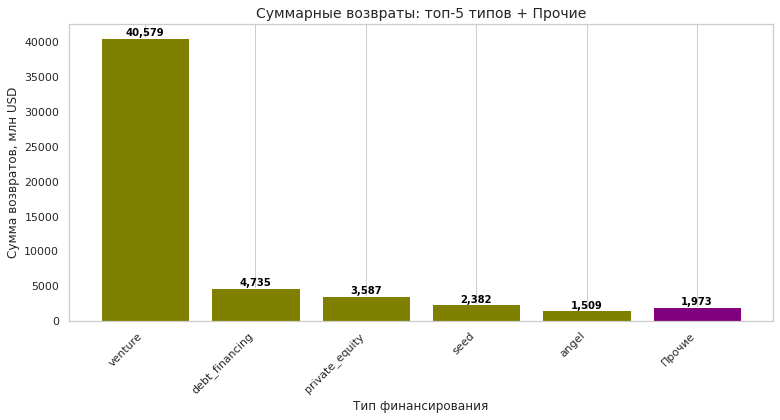

In [92]:
top_n = 5

# Выделяем топ‑5 и «Прочие»
top_cats = returns_sum.head(top_n)
other_sum = returns_sum[top_n:].sum()

# Формируем данные для графика: топ-5 + «Прочие»
plot_values = pd.concat([top_cats, pd.Series({'Прочие': other_sum})])

# Собираем данные в нужном порядке
labels = list(top_cats.index) + ['Прочие']
values = list(top_cats.values) + [other_sum]

# Задаём цвета: первые top_n — синие, «Прочие» — тёмно‑серый
colors = ['olive'] * top_n + ['purple']

# График
plt.figure(figsize=(11, 6))
bars = plt.bar(labels, values, color=colors)

# Подписи на столбцах
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

# Оформление осей и заголовка
plt.title(f'Суммарные возвраты: топ-{top_n} типов + Прочие', fontsize=14)
plt.xlabel('Тип финансирования', fontsize=12)
plt.ylabel('Сумма возвратов, млн USD', fontsize=12)
plt.xticks(rotation=45, ha='right')  # наклон подписей для длинных названий
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

# Выводим графика
plt.show()

Доминирующая категория — `venture` (венчурное финансирование): на неё приходится более 74% всех возвратов, что отражает фокус на высокопотенциальных проектах. 
Вторая и третья по значимости группы: `debt_financing` (8,65%) и `private_equity` (6,55%) — вместе дают ещё около 15%, то есть в сумме с venture покрывают почти 90% всех возвратов.
`Grant` (гранты): 0 — это логично, потому что гранты не предполагают возврата средств.

[Назад к содержанию](#start)


---

### Анализ динамики
<a id='11'></a>

***3.3.1 Динамика предоставления финансирования по годам***

Рассчитаем для каждой компании средний объём одного раунда финансирования на основе столбцов `funding_total_mln` и `funding_rounds`.

In [93]:
# Считаем средний объём одного раунда
df_final['avg_round_size_mln'] = df_final['funding_total_mln'] / df_final['funding_rounds']

In [94]:
# Извлекаем год из mid_funding_at
df_final['mid_year'] = df_final['mid_funding_at'].dt.year

In [95]:
# Агрегируем по годам: считаем медиану avg_round_size_mln и общее число раундов
yearly_stats = (
    df_final
    .groupby('mid_year')
    .agg(
        median_round_size_mln=('avg_round_size_mln', 'median'),
        total_rounds=('funding_rounds', 'sum')   # <-- именно это показывает активность рынка
    )
    .reset_index()
)
yearly_stats

,mid_year,median_round_size_mln,total_rounds
0,2000,2.12,112
1,2001,1.57,66
2,2002,3.23,98
3,2003,1.50,125
4,2004,3.00,181
5,2005,4.50,948
6,2006,3.88,1852
7,2007,2.88,2836
8,2008,2.18,3667
9,2009,1.50,4627


Отобразим графически динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования.

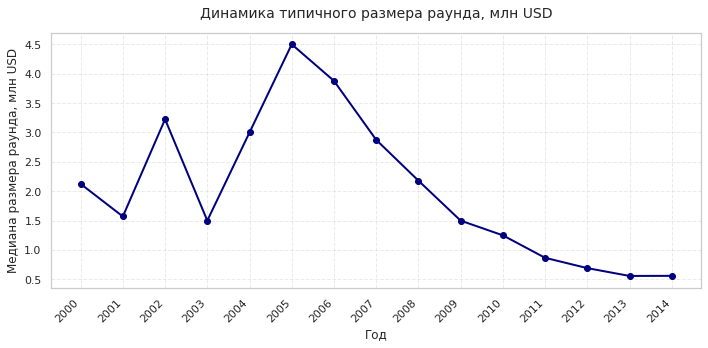

In [96]:
# Подготавливаем данные для графика
x = [int(v) for v in yearly_stats['mid_year']]
y = [float(v) for v in yearly_stats['median_round_size_mln']]

# Строим график
plt.figure(figsize=(10, 5))
plt.plot(x, y, marker='o', linewidth=2, markersize=6, color='navy')

# Оформление заголовка и осей
plt.title('Динамика типичного размера раунда, млн USD', fontsize=14, pad=15)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Медиана размера раунда, млн USD', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(x, rotation=45, ha='right')
plt.tight_layout()

# Вывод графика
plt.show()

Также визуализируем динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

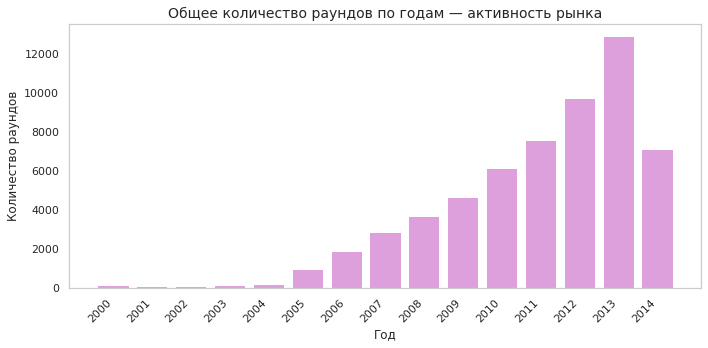

In [97]:
# Строим график
plt.figure(figsize=(10, 5))
plt.bar(yearly_stats['mid_year'], yearly_stats['total_rounds'], color='plum')

# Явно задаём все годы как метки на оси X
years = yearly_stats['mid_year'].astype(int).tolist()
plt.xticks(years, rotation=45, ha='right') 

# Оформление заголовка и осей
plt.title('Общее количество раундов по годам — активность рынка', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество раундов', fontsize=12)
plt.grid(False)
plt.tight_layout()

# Вывод графика
plt.show()

***ПРОМЕЖУТОЧНЫЙ ВЫВОД:***

* Максимальный медианный размер раунда — 4.50 млн USD — был зафиксирован в 2005 году.
* В 2014 году зафиксировано резкое снижение количества раундов финансирования (до 7 120 против 12 871 в 2013 году) при сохранении крайне низкого медианного размера раунда (0.56 млн USD). Однако следует учитывать, что данные за 2014 год предположительно неполные: наблюдается обрыв в конце года. В связи с этим снижение числа раундов может быть частично или полностью обусловлено недостающими данными. Медианный размер раунда, будучи устойчивой метрикой, менее чувствителен к обрыву.
* Снижение медианной суммы раунда при кратном росте их количества объясняется демократизацией отрасли и массовым переходом на ранние стадии инвестирования. Кризис 2008 года стал той точкой перелома: рынок перестал быть «рынком крупных ставок» и превратился в «рынок массовости», где основную долю по количеству составляют мелкие, частые сделки. С начала 2010-х годов барьеры для создания стартапа резко снизились благодаря облачным технологиям (SaaS, PaaS), что позволило запускать компании с минимальным чеком (Pre-seed/Seed) в сотни тысяч долларов вместо миллионов. Одновременно сформировалась глобальная инфраструктура микро-венчура: появились тысячи новых ангельских инвесторов, синдикаты и специализированные посевные фонды, которые начали массово дробить капитал между сотнями мелких сделок.

---
<a id='12'></a>
***3.3.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов***

Составим сводную таблицу, в которой укажем суммарный размер общего финансирования `funding_total_mln` по годам и сегментам рынка. Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

In [98]:
# Сводная таблица: суммарное финансирование по годам и сегментам
pivot_funding = (
    df_final
    .groupby(['mid_year', 'market'])['funding_total_mln']
    .sum()
    .unstack(fill_value=0)  # превращаем в таблицу: строки — годы, столбцы — сегменты
)

In [99]:
# Отбираем сегменты, где в 2014 году сумма больше, чем в 2013
growing_segments = pivot_funding.columns[pivot_funding.loc[2014] > pivot_funding.loc[2013]]

# Итоговая таблица — только растущие сегменты (по всем годам)
pivot_growing = pivot_funding[growing_segments]

pivot_growing

market,apps,big data,design,internet,manufacturing,medical,mid,niche,real estate,saas,startups,technology
mid_year,,,,,,,,,,,,
2000,0.00,0.00,0.00,10.00,56.66,24.00,82.44,8.84,2.50,0.00,0.00,0.00
2001,0.00,0.00,0.00,0.00,2.37,0.00,9.44,27.54,0.00,0.00,0.00,22.16
2002,0.00,0.00,0.00,1.10,0.00,0.00,18.89,0.24,5.28,2.00,0.00,11.00
2003,0.00,0.00,0.00,0.00,4.27,0.00,43.24,4.16,6.29,0.00,0.00,0.00
2004,0.00,0.00,0.00,10.50,3.00,0.00,54.44,10.85,0.00,0.00,0.00,1.75
2005,0.00,0.00,9.30,1.77,61.77,11.09,214.41,28.38,0.25,5.24,0.00,50.73
2006,1.31,0.00,0.71,0.01,163.96,20.25,347.52,64.03,2.08,4.79,0.00,22.79
2007,0.00,7.78,10.80,4.50,147.73,2.10,503.54,43.93,33.22,14.65,0.00,180.19
2008,4.30,2.45,5.94,23.41,173.05,28.81,550.37,91.26,46.61,27.23,5.01,277.73


На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у нас достаточно данных (`manufacturing`, `medical`, `real estate`, `technology`) . Рассматрим только массовые сегменты, а средние и нишевые исключим.

In [100]:
# Исключаем средние и нишевые сегменты
non_massive = ['mid', 'niche']
massive_candidates = pivot_growing .columns.difference(non_massive)
pivot_massive = pivot_growing[massive_candidates]

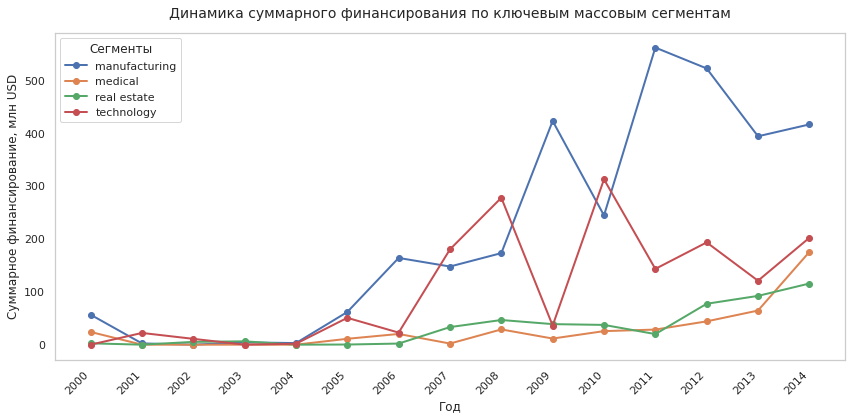

In [101]:
# Список сегментов, которые хотим отобразить
target_segments = ['manufacturing', 'medical', 'real estate', 'technology']

# Строим график
plt.figure(figsize=(12, 6))

for col in target_segments:
    plt.plot(
        pivot_massive.index,
        pivot_massive[col],
        marker='o',
        label=col,
        linewidth=2
    )

# Оформляем заговолок и оси
plt.title('Динамика суммарного финансирования по ключевым массовым сегментам', fontsize=14, pad=15)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Суммарное финансирование, млн USD', fontsize=12)
plt.legend(title='Сегменты', loc='upper left')
plt.grid(False)
plt.xticks(pivot_massive.index.astype(int), rotation=45, ha='right')
plt.tight_layout()

# Выводим график
plt.show()

***ПРОМЕЖУТОЧНЫЕ ВЫВОДЫ:***

Сегменты демонстрирующие устойчивый восходящий тренд:
* ***manufacturing*** - устойчивый рост на протяжении всего периода, с заметным ускорением в последние годы. Рост 2014 к 2013: 416,33 млн USD против 393,94 млн USD — небольшой, но стабильный прирост (~5,7 %). Особенность: сегмент демонстрирует последовательное наращивание объёмов без резких провалов, что говорит о системной активности инвесторов.
* ***medical*** - один из самых динамичных сегментов — с 24 млн USD в 2000 году до 175,24 млн USD в 2014 году. Рост 2014 к 2013: резкий скачок — 175,24 против 64,47 млн USD (+172 %). Особенность: именно в 2014 году произошёл мощный всплеск, который сильно выделяет сегмент на фоне остальных. Даже с учётом возможной неполноты данных за 2014 год такой масштаб роста выглядит значимым.
* ***technology*** - стабильный рост с 2005 года, с пиками в 2008 и 2010 годах и последующим восстановлением. Рост 2014 к 2013: 202,02 против 120,87 млн USD (+67 %). Особенность: сегмент сохраняет высокую волатильность, но тренд — явно восходящий. Это классический «драйвер» венчурного рынка, где крупные раунды заметно двигают годовые суммы.
* ***real estate*** - плавный, но уверенный рост с 2002 года. Рост 2014 к 2013: 115,57 против 92,21 млн USD (+25 %). Особенность: отсутствие резких провалов и стабильный прирост делают сегмент предсказуемым.


---
<a id='13'></a>
***3.3.3 Годовая динамика доли возвращённых средств по типам финансирования***

Для понимания какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам, рассчитаем  для каждого года и каждого типа финансирования нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, заменим на пропуски.

In [102]:
# Ранее был создат список типов финансирования cols
# Группируем по годам и суммируем привленные средства по типу финансирования
df_funded_by_year = (
    df_final
    .groupby('mid_year')[cols]
    .sum()
    .fillna(0)
)

# Переводим из USD в млн USD
df_funded_by_year_mln = df_funded_by_year / 1_000_000

# Объединяем по индексу (году) — используем join, чтобы соединить по индексам
df_joined = df_funded_by_year_mln.join(df_return, how='outer', rsuffix='_return')            

In [103]:
# Чтобы избежать деления на ноль, создадим небольшое число, которое добавим к знаменателю
eps = 1e-60
ratio_cols = []

for c in cols:
    funded_col = c
    return_col = f"{c}_return"
    ratio_col = f"{c}_ratio"
# Для каждого типа считаем долю возврата: возврат / (привлёченные + eps)
    df_joined[ratio_col] = df_joined[return_col] / (df_joined[funded_col] + eps)
    ratio_cols.append(ratio_col)

In [104]:
cols_plot = ratio_cols

for col in cols_plot:
    # Приводим к float: всё нечисловое станет NaN
    df_joined[col] = pd.to_numeric(df_joined[col], errors='coerce')
    # Обрезаем аномально большие значения (>5.0) в NaN
    mask_too_high = df_joined[col] > 5.0
    df_joined.loc[mask_too_high, col] = float('nan')
    
# Посмотрим итоговую таблицу
df_joined

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,seed_return,venture_return,equity_crowdfunding_return,undisclosed_return,convertible_note_return,debt_financing_return,angel_return,grant_return,private_equity_return,post_ipo_equity_return,post_ipo_debt_return,secondary_market_return,product_crowdfunding_return,seed_ratio,venture_ratio,equity_crowdfunding_ratio,undisclosed_ratio,convertible_note_ratio,debt_financing_ratio,angel_ratio,grant_ratio,private_equity_ratio,post_ipo_equity_ratio,post_ipo_debt_ratio,secondary_market_ratio,product_crowdfunding_ratio
mid_year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2000,16.76,327.96,0.00,104.60,0.00,14.00,24.09,0.29,0.00,3.47,0.00,7.72,0.00,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.00,0.00,0.94,0.00,0.20,0.00,1.00,0.17,0.00,0.75,0.00,0.62,0.27,0.00,0.00,0.27,0.00,0.03,0.00
2001,4.10,208.32,0.00,37.72,1.50,5.83,1.00,0.10,0.00,0.00,0.00,0.00,0.00,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.00,0.00,0.46,0.00,0.46,0.00,0.70,0.11,0.00,0.57,0.01,0.77,1.18,0.00,0.00,NaN,0.00,NaN,0.00
2002,10.47,306.94,0.00,42.32,0.00,15.31,3.00,0.00,7.50,0.30,0.00,0.00,0.00,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.00,1.51,0.34,0.00,0.06,0.00,0.63,0.68,0.00,0.61,NaN,0.22,1.14,0.00,0.20,1.13,0.00,NaN,0.00
2003,15.32,372.23,0.00,10.28,0.00,1.05,5.63,16.85,0.00,0.00,0.00,0.00,0.00,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.00,1.62,2.11,0.00,0.08,0.00,0.51,0.63,0.00,0.91,NaN,1.04,0.61,0.00,NaN,NaN,0.00,NaN,0.00
2004,18.10,664.15,0.00,62.91,0.00,30.82,11.01,10.36,0.00,0.00,0.00,0.00,0.00,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.00,2.19,3.38,0.00,0.55,0.00,0.55,0.84,0.00,0.53,NaN,0.44,0.83,0.00,NaN,NaN,0.00,NaN,0.00
2005,39.43,"4,809.71",0.00,8.87,0.00,101.72,60.91,6.27,5.00,4.80,0.00,0.00,0.00,26.60,"2,628.92",0.00,9.51,0.02,35.09,31.06,0.00,2.40,3.51,0.00,0.05,0.00,0.67,0.55,0.00,1.07,NaN,0.34,0.51,0.00,0.48,0.73,0.00,NaN,0.00
2006,66.79,"9,027.40",0.93,61.55,10.70,140.85,70.76,6.15,17.82,0.00,0.00,0.00,0.00,61.81,"3,100.18",0.19,46.74,1.78,113.21,47.75,0.00,16.67,20.58,0.00,0.12,0.00,0.93,0.34,0.20,0.76,0.17,0.80,0.67,0.00,0.94,NaN,0.00,NaN,0.00
2007,192.30,"12,026.00",0.00,109.65,14.12,208.60,201.15,34.24,153.37,12.00,0.00,0.00,0.00,70.41,"3,585.37",0.01,55.37,3.22,125.68,164.51,0.00,88.81,24.36,0.00,0.57,0.00,0.37,0.30,NaN,0.50,0.23,0.60,0.82,0.00,0.58,2.03,0.00,NaN,0.00
2008,297.93,"14,265.94",0.00,119.92,28.60,425.12,249.30,23.49,191.76,36.00,0.00,0.00,1.00,89.72,"2,717.02",0.03,41.02,1.71,397.54,102.83,0.00,130.38,84.28,0.00,0.47,0.00,0.30,0.19,NaN,0.34,0.06,0.94,0.41,0.00,0.68,2.34,0.00,NaN,0.00


Построим график, на котором изобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

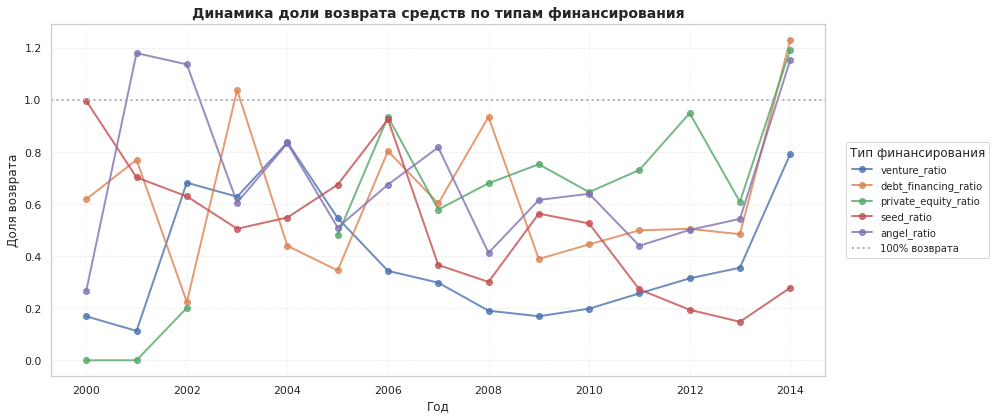

In [105]:
# Настройка стиля 
sns.set(style="whitegrid")

# Список типов финансирования, которые нужны для графика
target_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# Формируем имена колонок с коэффициентами возврата для этих типов
plot_cols = [f"{t}_ratio" for t in target_types if f"{t}_ratio" in df_joined.columns]

# Подготовка данных
df_plot = df_joined[plot_cols].copy()
df_plot.index.name = 'year' 

# Построение графика
plt.figure(figsize=(14, 6))
ax = df_plot.plot(
    marker='o',
    linewidth=2,
    markersize=6,
    alpha=0.8,
    ax=plt.gca()
)

# Сетка
ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.3)
ax.grid(True, which='major', axis='x', linestyle='-.', alpha=0.2)

# Оформление
ax.set_title('Динамика доли возврата средств по типам финансирования', fontsize=14, weight='bold')
ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('Доля возврата', fontsize=12)

# Линия 100% возврата 
ax.axhline(1.0, color='darkgray', linestyle=':', linewidth=2, alpha=0.9, label='100% возврата')
# Легенда
ax.legend(title='Тип финансирования', loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, frameon=True)

plt.tight_layout()

# Выводим график
plt.show()

***ПРОМЕЖУТОЧНЫЕ ВЫВОДЫ***:

Типы финансирования с наиболее устойчивым ростом доли возврата средств:

* ***Private Equity (зелёный столбец).*** Этот тип демонстрирует выраженную положительную динамику в период с 2005 по 2014 год: после относительно низких значений в начале 2000‑х наблюдается стабильный рост с несколькими пиковыми значениями (в частности, заметный подъём в 2012 и 2014 годах). Тренд выглядит последовательным, без резких провалов, что говорит о нарастающей эффективности этого типа финансирования.
* ***Debt Financing (оранжевый столбец).*** Для долгового финансирования также прослеживается тенденция к увеличению доли возврата, особенно в 2006–2008 годах и в финальной фазе периода (2013–2014). Хотя динамика менее гладкая, чем у Private Equity, общий вектор направлен вверх, а значения в конце периода стабильно превышают показатели начала 2000‑х.

Однако, динамика показателя (рост или падение) — это не полноценный вывод об эффективности самого типа финансирования. На цифры влияет сразу несколько факторов, и иногда тренд отражает не свойства инструмента, а внешние обстоятельства или особенности конкретных сделок. 

[Назад к содержанию](#start)

---

## Итоговый вывод  и рекомендации:
<a id='14'></a>
### Обзор проделанной работы

В ходе исследования мы проанализировали данные 40900 компаний, которые привлекали внешнее финансирование на различных стадиях развития, с детализацией по типам инвестиций (венчурные, долговые, ангельские, прямые вложения и др.) и этапам привлечения средств, а также с учётом их географической привязки, отраслевой принадлежности и текущего статуса деятельности. Была проведена последовательная очистка исходных данных от пропусков и дубликатов, также проведен исследовательский анализ для решения поставленных задач.

<a id='15'></a>
### Ответы на исследовательские вопросы

Исследовательский анализ был поделен на три части.

***1. Инжиниринг признаков***

Наблюдается выраженный дисбаланс: большинство компаний (59%) ограничиваются одним раундом финансирования, что характерно для посевных стадий или неудачных проектов. При этом основной объём инвестиций (более 61.9 %) концентрируется в относительно небольшой группе компаний (30.05%) с длительным циклом финансирования, что подчёркивает важность устойчивости и последовательного развития для привлечения значительных капиталовложений.

***2. Работа с выбросами и анализ типов финансирования***

- Доля компаний с аномальным объёмом финансирования (по IQR) в топ‑10 сегментах (`real estate`, `entertainment`, `consulting` и др.) — 15–17 %. Это типично для крупных, динамично развивающихся рынков, где наряду с массовыми проектами встречаются «единороги» с кратно завышенными объёмами.
- Типичный размер финансирования (медиана): 1.31 млн USD. Интервал, в котором лежат типичные значения: 0.25 – 5.00 млн USD.
- При анализе полноты данных за 2014 год было обнаружено резкое падение событий в декабре. Многие компании попали в категорию «последний раунд в 2014» формально: раунды после этого года в датасет не включены. 
- Абсолютный лидер по объёмам привлеченных средств (более 80% от общей суммы), популярности - наибольшее число сделок (18 836 сделок) и суммарным объёмам возврата (74%) - `venture`.
- Типы финансирования, которые часто встречаются, но характеризуются небольшими объёмами: `seed`, `angel`, `equity_crowdfunding`, `convertible note`.
- Типы финансирования, которые встречаются редко, но характеризуются значительным объёмом: `private equity`, `post-ipo debt`, `debt financing`, `post_ipo_equity`.

***3. Анализ динамики***

* Исторический пик медианного размера раунда (4.50 млн USD) пришёлся на 2005 год. Резкое падение числа раундов в 2014 году до 7 120 при сохранении низкого медиана (0,56 млн USD), вероятнее всего, является артефактом неполных данных из-за обрыва выборки в конце года.
* В период с 2000 по 2014 год ряд сегментов демонстрирует устойчивый рост суммарного объема привлеченных средств. Особенно заметна положительная динамика в сегментах `medical`, `manufacturing`, `technology` и `real estate`. Существенный прирост совокупного капитала в этих направлениях при сокращении числа сделок указывает не только на растущую привлекательность отраслей для инвесторов, но и на значительное укрупнение среднего чека внутри данных сегментов.
* Наиболее устойчивый положительный тренд доли возвращённых средств демонстрируют типы `private equity` и `debt financing`, но различаются по характеру динамики: `private equity` — более стабильный и предсказуемый рост, `debt financing` — более волатильный, но также положительный тренд.  

Выводы в целом согласуются и дополняют друг друга, формируя целостную картину венчурного рынка -  концентрацию капитала, неоднородность проектов и влияние качества данных на интерпретацию динамики. Однако утверждение о 74% суммарном возврате от `venture` может быть некорректным, так как данные за 2014 год обрезаны и фонды поздних стадий просто не успели завершить циклы выхода, а молодые компании физически не могли вернуть средства. 

<a id='16'></a>
### Рекомендации на основе анализа данных

***На основании анализа динамики рынка наиболее перспективными выглядят следующие отрасли:***

- `Medical`. Отрасль показывает устойчивый рост суммарного объёма привлечённых средств. Это говорит о возрастающем спросе на медицинские инновации. При этом отрасль традиционно имеет длительные циклы разработки и выхода на прибыль — это соответствует модели «долгосрочного капитала», где важнее не скорость, а потенциал масштабирования и барьеры для входа.
- `Technology`. Сегмент демонстрирует стабильный приток капитала и высокую динамику, а также более короткие циклы возврата по сравнению с `medical`. Здесь особенно востребованы проекты с быстрым выходом на метрики роста.
- `Manufacturing`. Рост объёмов при сокращении числа сделок указывает на укрупнение проектов и переход к более зрелым, капиталоёмким инициативам — это снижает риски «мелких неудачных ставок» и повышает вероятность системного эффекта от вложений. 
- `Real estate`. Рынок недвижимости демонстрирует прирост совокупного капитала, но в венчурном контексте он часто связан не с инновациями, а с классическими капитальными вложениями.

Приоритетный выбор: `technology` или `medical`. Причины: высокий инновационный потенциал; долгосрочные тренды (старение населения, цифровизация); диверсификация рисков внутри каждой отрасли.

***Рекомендация по типу финансирования***

Если цель стабильный возврат и минимизация рисков, оптимально сочетать два типа финансирования:
* `Private equity` — для основной части портфеля. Демонстрирует самый устойчивый и предсказуемый рост доли возвращённых средств, ориентирован на зрелые компании с доказанной бизнес‑моделью, позволяет участвовать в управлении и контролировать риски.
* `Debt financing` — как дополнение (15–20 % портфеля). Показывает положительный тренд доли возврата, несмотря на волатильность, имеет фиксированный доход (проценты), что снижает зависимость от рыночной конъюнктуры, обеспечивает диверсификацию: менее коррелирует с венчурными рисками.

***Итоговая стратегия.***
* Отрасли: сосредоточиться на `technology` и `medical`, с небольшим аллокацией в `manufacturing` и `real estate` для диверсификации.
* Тип финансирования:
 - 60–70 % — `private equity` (стабильные доходные активы);
 - 15–20 % — `debt financing` (фиксированный доход, снижение волатильности);
 - 10–15 % — точечные `venture`-инвестиции в прорывные стартапы внутри приоритетных отраслей.

Также выбирать тип финансирования можно в соответствии со стадиями проекта и горизонтами возврата. Как вариант оптимальной стратегии на 2015 год — смешанный портфель: ставка на растущие сегменты (`medical`, `technology`, `manufacturing`) с распределением по стадиям (`seed`/`angel` для ранних, `venture` для масштабирования, `private equity/debt` для зрелых проектов) и учётом длительных циклов возврата в части отраслей.

[Назад к содержанию](#start)